# **Mental Health Data Analysis**

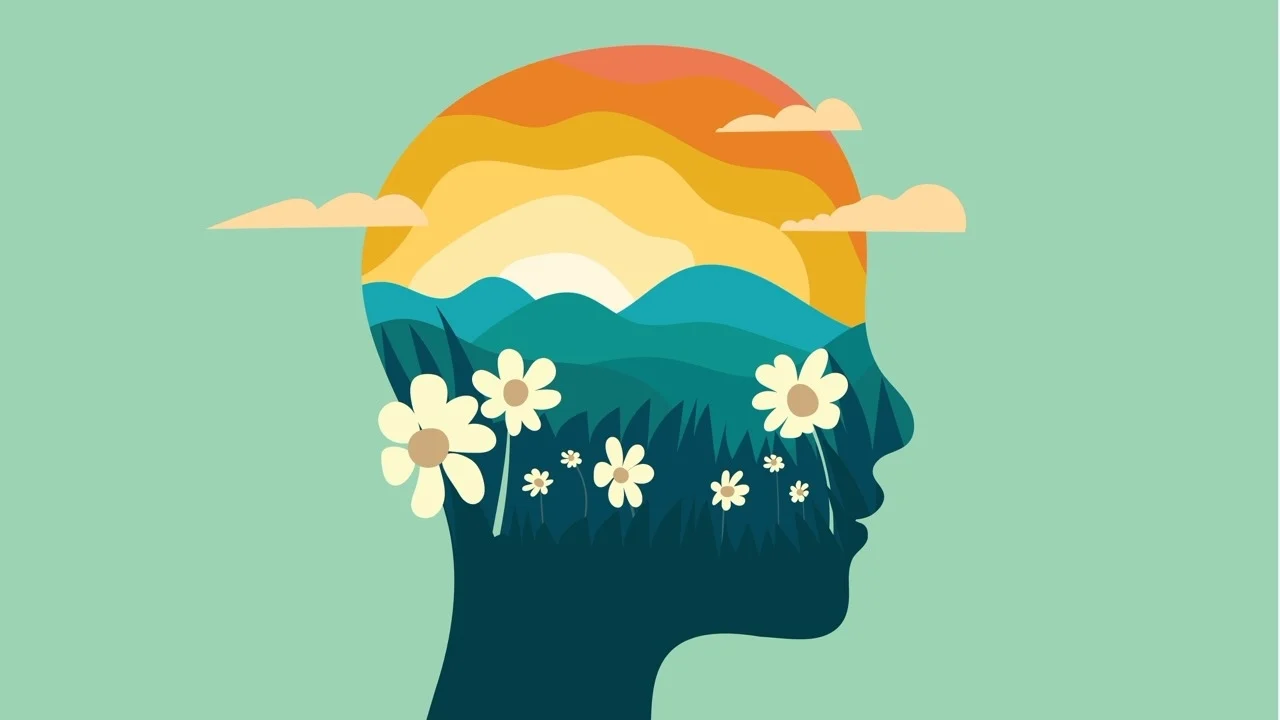

## **1. Import libraries**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import numpy as np


from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import model_selection
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error

## **2. Load data**

In [5]:
df = pd.read_sas('LLCP2024.XPT', format='xport')

In [6]:
#dataset overview
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


In [7]:
df.shape

(457670, 301)

Dataset is observed to be very large with 457670 rows and 301 columns. With many unnecessary columns, we selected the following columns that would be relevent to mental health.


In [8]:
#New Dataset
mental_health_df1 = df[[
    "_SEX",
    "PHYSHLTH",
    "MENTHLTH",
    "MEDCOST1",
    "EXERANY2",
    "ADDEPEV3",
    "MARITAL",
    "EDUCA",
    "RENTHOM1",
    "VETERAN3",
    "EMPLOY1",
    "CHILDREN",
    "INCOME3",
    "PREGNANT",
    "WEIGHT2",
    "HEIGHT3",
    "DEAF",
    "BLIND",
    "DECIDE",
    "DIFFWALK",
    "DIFFDRES",
    "DIFFALON",
    "PREDIAB2",
    "CIMEMLO1",
    "ACEDEPRS",
    "ACEDRUGS",
    "ACEDIVRC",
    "ACEPUNCH",
    "ACEHURT1",
    "ACEHVSEX",
    "ACEADSAF",
    "ACEADNED",
    "LSATISFY",
    "SDLONELY",
    "_RACE",
    "_AGE_G",
    "SDHUTILS",
    "HOWSAFE1",
    "MARIJAN1",
    "SOMALE",
    "_URBSTAT",
    "_HLTHPL2",
    "_SMOKER3",
    "_RFDRHV9"
]].copy()

## **3. Data Dictionaries**

| **Feature**   | **Description**                                                                 |
|---------------|---------------------------------------------------------------------------------|
| _SEX          | Sex of respondent (Male/Female)                                                 |
| PHYSHLTH      | Number of days physical health was not good (past 30 days)                      |
| MENTHLTH      | Number of days mental health was not good (past 30 days)                        |
| MEDCOST1      | Could not see a doctor due to cost (1=Yes, 2=No)                                |
| EXERANY2      | Exercised in the past 30 days (1=Yes, 2=No)                                     |
| ADDEPEV3      | Ever diagnosed with a depressive disorder (1=Yes, 2=No)                         |
| MARITAL       | Marital status                                                                  |
| EDUCA         | Education level                                                                 |
| RENTHOM1      | Own or rent home                                                                |
| VETERAN3      | Veteran status                                                                  |
| EMPLOY1       | Employment status                                                               |
| CHILDREN      | Number of children in household                                                 |
| INCOME3       | Income level                                                                    |
| PREGNANT      | Pregnancy status                                                                |
| WEIGHT2       | Reported weight                                                                 |
| HEIGHT3       | Reported height                                                                 |
| DEAF          | Serious difficulty hearing (1=Yes, 2=No)                                         |
| BLIND         | Serious difficulty seeing (1=Yes, 2=No)                                          |
| DECIDE        | Difficulty concentrating or remembering                                         |
| DIFFWALK      | Difficulty walking or climbing stairs                                           |
| DIFFDRES      | Difficulty dressing or bathing                                                  |
| DIFFALON      | Difficulty doing errands alone                                                  |
| PREDIAB2      | Prediabetes or borderline diabetes status                                       |
| CIMEMLO1      | Increasing difficulty with thinking or memory                                   |
| ACEDEPRS      | Lived with someone depressed or mentally ill                                    |
| ACEDRUGS      | Lived with someone who used drugs or abused prescriptions                       |
| ACEDIVRC      | Parents divorced or separated                                                   |
| ACEPUNCH      | Parents physically fought each other                                            |
| ACEHURT1      | Physically hurt by a parent or adult                                            |
| ACEHVSEX      | Forced to have sex                                                              |
| ACEADSAF      | Felt safe and protected during childhood                                        |
| ACEADNED      | Basic needs met during childhood                                                |
| LSATISFY      | Satisfaction with life                                                          |
| SDLONELY      | Frequency of feeling lonely                                                     |
| _RACE         | Race/ethnicity category                                                         |
| _AGE_G        | Age group                                                                       |
| SDHUTILS      | Difficulty paying utility bills                                                 |
| HOWSAFE1      | Perceived neighborhood safety                                                   |
| MARIJAN1      | Marijuana use in past 30 days                                                   |
| SOMALE        | Sexual orientation                                                              |
| _URBSTAT      | Urban or rural residence                                                        |
| _HLTHPL2      | Health insurance coverage                                                       |
| _SMOKER3      | Smoking status                                                                  |
| _RFDRHV9      | Heavy drinking indicator                                                        |

## **4. Data profiling**

In [9]:
#viewing the first 10 rows
mental_health_df1.head(10)

,_SEX,PHYSHLTH,MENTHLTH,MEDCOST1,EXERANY2,ADDEPEV3,MARITAL,EDUCA,RENTHOM1,VETERAN3,...,_RACE,_AGE_G,SDHUTILS,HOWSAFE1,MARIJAN1,SOMALE,_URBSTAT,_HLTHPL2,_SMOKER3,_RFDRHV9
0,2.0,2.0,88.0,2.0,1.0,2.0,3.0,4.0,1.0,2.0,...,1.0,6.0,2.0,1.0,NaN,NaN,1.0,1.0,4.0,1.0
1,1.0,88.0,88.0,2.0,1.0,2.0,1.0,6.0,1.0,1.0,...,1.0,6.0,2.0,1.0,NaN,2.0,1.0,1.0,3.0,1.0
2,1.0,30.0,88.0,1.0,1.0,2.0,6.0,5.0,1.0,1.0,...,1.0,5.0,2.0,1.0,NaN,2.0,1.0,1.0,1.0,1.0
3,1.0,88.0,88.0,2.0,1.0,2.0,1.0,6.0,1.0,2.0,...,1.0,6.0,2.0,2.0,NaN,2.0,1.0,1.0,4.0,1.0
4,1.0,88.0,88.0,2.0,2.0,2.0,5.0,5.0,1.0,2.0,...,1.0,4.0,2.0,1.0,NaN,2.0,1.0,1.0,4.0,1.0
5,1.0,7.0,88.0,2.0,1.0,2.0,1.0,4.0,2.0,2.0,...,1.0,4.0,2.0,2.0,NaN,2.0,1.0,1.0,4.0,1.0
6,2.0,88.0,88.0,2.0,1.0,2.0,1.0,5.0,1.0,2.0,...,1.0,6.0,2.0,2.0,NaN,NaN,2.0,1.0,4.0,1.0
7,2.0,30.0,88.0,2.0,2.0,2.0,1.0,5.0,1.0,2.0,...,1.0,6.0,2.0,1.0,NaN,NaN,2.0,1.0,4.0,1.0
8,2.0,5.0,88.0,2.0,1.0,2.0,1.0,4.0,1.0,2.0,...,1.0,6.0,2.0,2.0,NaN,NaN,1.0,1.0,4.0,1.0
9,1.0,14.0,88.0,2.0,1.0,2.0,3.0,5.0,1.0,1.0,...,1.0,6.0,2.0,1.0,NaN,2.0,1.0,1.0,3.0,1.0


In [10]:
#data information
mental_health_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 44 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _SEX      457670 non-null  float64
 1   PHYSHLTH  457665 non-null  float64
 2   MENTHLTH  457667 non-null  float64
 3   MEDCOST1  457664 non-null  float64
 4   EXERANY2  457667 non-null  float64
 5   ADDEPEV3  457665 non-null  float64
 6   MARITAL   457661 non-null  float64
 7   EDUCA     457663 non-null  float64
 8   RENTHOM1  457662 non-null  float64
 9   VETERAN3  456435 non-null  float64
 10  EMPLOY1   454367 non-null  float64
 11  CHILDREN  452064 non-null  float64
 12  INCOME3   448401 non-null  float64
 13  PREGNANT  81363 non-null   float64
 14  WEIGHT2   445337 non-null  float64
 15  HEIGHT3   444270 non-null  float64
 16  DEAF      442592 non-null  float64
 17  BLIND     441422 non-null  float64
 18  DECIDE    440229 non-null  float64
 19  DIFFWALK  438998 non-null  float64
 20  DIFF

In [11]:
#shape of the data
mental_health_df1.shape

(457670, 44)

In [12]:
mental_health_df1.describe().round(2)

,_SEX,PHYSHLTH,MENTHLTH,MEDCOST1,EXERANY2,ADDEPEV3,MARITAL,EDUCA,RENTHOM1,VETERAN3,...,_RACE,_AGE_G,SDHUTILS,HOWSAFE1,MARIJAN1,SOMALE,_URBSTAT,_HLTHPL2,_SMOKER3,_RFDRHV9
count,457670.00,457665.00,457667.00,457664.00,457667.00,457665.00,457661.00,457663.00,457662.00,456435.00,...,457670.00,457670.00,202008.00,201389.00,136832.00,123077.00,443047.00,457670.00,457670.00,457670.00
mean,1.52,57.92,57.73,1.93,1.25,1.82,2.46,5.04,1.42,1.90,...,2.29,4.39,1.95,1.69,77.82,2.22,1.13,1.38,3.81,1.87
std,0.50,37.87,38.07,0.45,0.55,0.60,1.83,1.05,0.87,0.49,...,2.51,1.64,0.41,0.77,25.48,1.14,0.34,1.58,1.66,2.41
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.00,12.00,10.00,2.00,1.00,2.00,1.00,4.00,1.00,2.00,...,1.00,3.00,2.00,1.00,88.00,2.00,1.00,1.00,3.00,1.00
50%,2.00,88.00,88.00,2.00,1.00,2.00,1.00,5.00,1.00,2.00,...,1.00,5.00,2.00,2.00,88.00,2.00,1.00,1.00,4.00,1.00
75%,2.00,88.00,88.00,2.00,1.00,2.00,4.00,6.00,2.00,2.00,...,2.00,6.00,2.00,2.00,88.00,2.00,1.00,1.00,4.00,1.00
max,2.00,99.00,99.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,...,9.00,6.00,9.00,9.00,99.00,9.00,2.00,9.00,9.00,9.00


## **5. Data cleaning**

### Checking N/A Values

In [13]:
#checking for null values in the dataset
mental_health_df1.isnull().sum().sort_values(ascending = False)

ACEADNED    418922
ACEADSAF    418866
ACEHVSEX    418787
ACEHURT1    418619
ACEPUNCH    418574
ACEDIVRC    418527
ACEDRUGS    418487
ACEDEPRS    418387
CIMEMLO1    378560
PREGNANT    376307
SOMALE      334593
MARIJAN1    320838
PREDIAB2    298475
HOWSAFE1    256281
SDHUTILS    255662
SDLONELY    254469
LSATISFY    253906
DIFFALON     20533
DIFFDRES     19459
DIFFWALK     18672
DECIDE       17441
BLIND        16248
DEAF         15078
_URBSTAT     14623
HEIGHT3      13400
WEIGHT2      12333
INCOME3       9269
CHILDREN      5606
EMPLOY1       3303
VETERAN3      1235
MARITAL          9
RENTHOM1         8
EDUCA            7
MEDCOST1         6
ADDEPEV3         5
PHYSHLTH         5
EXERANY2         3
MENTHLTH         3
_SMOKER3         0
_HLTHPL2         0
_SEX             0
_AGE_G           0
_RACE            0
_RFDRHV9         0
dtype: int64

####__🚨 Variables with more than 200,000 N/A values:__

* ACEADNED: Did an adult make sure basic needs were met
* ACEADSAF: Did an adult make you feel safe and protected
* ACEHVSEX: How Often Did Anyone Ever Force You to Have Sex?
* ACEHURT1: How Often Did A Parent Physically Hurt You In Any Way?
* ACEPUNCH: How Often Did Your Parents Beat Each Other Up?
* ACEDIVRC:  Were your parents separated or divorced?
* ACEDRUGS:  Did you live with anyone who used illegal street drugs or who abused prescription medications?
* ACEDEPRS:  Did you live with anyone who was depressed, mentally ill, or suicidal?
* LANDSEX3: Are you male or female?
* CIMEMLO1: Have you experienced difficulties with thinking or memory that is happening more often or is getting worse?
* PREGNANT: To your knowledge, are you now pregnant?
* SOMALE: Sexual orientation
* MARIJAN1:  During the past 30 days, on how many days did you use marijuana or cannabis?
* PREDIAB2: Pre-Diabetes
* HOWSAFE1: Neighborhood Safe From Crime
* SDHUTILS: Were you not able to pay utility bills or threatened to lose service?
* SDLONELY:  How often do you feel lonely?
* LSATISFY: Satisfaction with life

### Handling Variables with more than 200,000 N/A values

In [14]:
mental_health_df = mental_health_df1.loc[:, mental_health_df1.isna().sum() <= 200000].copy()

In [15]:
mental_health_df.isnull().sum().sort_values(ascending = False)

DIFFALON    20533
DIFFDRES    19459
DIFFWALK    18672
DECIDE      17441
BLIND       16248
DEAF        15078
_URBSTAT    14623
HEIGHT3     13400
WEIGHT2     12333
INCOME3      9269
CHILDREN     5606
EMPLOY1      3303
VETERAN3     1235
MARITAL         9
RENTHOM1        8
EDUCA           7
MEDCOST1        6
PHYSHLTH        5
ADDEPEV3        5
EXERANY2        3
MENTHLTH        3
_SMOKER3        0
_HLTHPL2        0
_SEX            0
_AGE_G          0
_RACE           0
_RFDRHV9        0
dtype: int64

In [16]:
mental_health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 27 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _SEX      457670 non-null  float64
 1   PHYSHLTH  457665 non-null  float64
 2   MENTHLTH  457667 non-null  float64
 3   MEDCOST1  457664 non-null  float64
 4   EXERANY2  457667 non-null  float64
 5   ADDEPEV3  457665 non-null  float64
 6   MARITAL   457661 non-null  float64
 7   EDUCA     457663 non-null  float64
 8   RENTHOM1  457662 non-null  float64
 9   VETERAN3  456435 non-null  float64
 10  EMPLOY1   454367 non-null  float64
 11  CHILDREN  452064 non-null  float64
 12  INCOME3   448401 non-null  float64
 13  WEIGHT2   445337 non-null  float64
 14  HEIGHT3   444270 non-null  float64
 15  DEAF      442592 non-null  float64
 16  BLIND     441422 non-null  float64
 17  DECIDE    440229 non-null  float64
 18  DIFFWALK  438998 non-null  float64
 19  DIFFDRES  438211 non-null  float64
 20  DIFF

### Handling N/A values in other columns and fixing values format

#### _SEX

In [17]:
#Value is seen to be 1 and 2 -> it needs to be changed to 0 and 1 for noraml format
#Original Male = 1 and Female = 2 -> Male = 0 and Female = 1
mental_health_df['_SEX'].value_counts()

_SEX
2.0    240163
1.0    217507
Name: count, dtype: int64

In [18]:
mental_health_df['_SEX'] = mental_health_df['_SEX'].replace({1: 0, 2: 1})

In [19]:
mental_health_df['_SEX'].value_counts()

_SEX
1.0    240163
0.0    217507
Name: count, dtype: int64

#### PHYSHLTH

In [20]:
#Fixing PHYSHLTH value format
mental_health_df['PHYSHLTH'].value_counts()

PHYSHLTH
88.0    267576
30.0     36353
2.0      27903
1.0      18505
3.0      16919
5.0      16155
10.0     11130
15.0      9805
7.0       9385
4.0       9023
77.0      8765
20.0      6492
14.0      4667
6.0       2495
25.0      2494
99.0      2297
8.0       1856
12.0      1120
21.0       982
28.0       897
9.0        418
29.0       411
18.0       343
16.0       299
27.0       246
22.0       209
17.0       198
13.0       156
26.0       139
11.0       135
24.0       118
23.0       117
19.0        57
Name: count, dtype: int64

In [21]:
#Answer "None"= 88, we  change it to 0
mental_health_df['PHYSHLTH'] = mental_health_df['PHYSHLTH'].replace({88: 0})

#Answer "Not sure"= 77, "Refused"= 99, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'PHYSHLTH' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['PHYSHLTH'] = mental_health_df['PHYSHLTH'].replace([77, 99], np.nan)

median_val = mental_health_df['PHYSHLTH'].median()
mental_health_df['PHYSHLTH'] = mental_health_df['PHYSHLTH'].fillna(median_val)

mental_health_df['PHYSHLTH'].value_counts()

PHYSHLTH
0.0     278643
30.0     36353
2.0      27903
1.0      18505
3.0      16919
5.0      16155
10.0     11130
15.0      9805
7.0       9385
4.0       9023
20.0      6492
14.0      4667
6.0       2495
25.0      2494
8.0       1856
12.0      1120
21.0       982
28.0       897
9.0        418
29.0       411
18.0       343
16.0       299
27.0       246
22.0       209
17.0       198
13.0       156
26.0       139
11.0       135
24.0       118
23.0       117
19.0        57
Name: count, dtype: int64

#### MENTHLTH  

In [22]:
mental_health_df['MENTHLTH'].value_counts()

MENTHLTH
88.0    269909
30.0     27295
2.0      25180
5.0      21369
10.0     16465
3.0      15961
1.0      15412
15.0     15317
20.0      9721
4.0       8381
7.0       8277
77.0      5594
25.0      3346
14.0      2847
99.0      2559
6.0       2374
8.0       1873
12.0      1334
28.0       932
21.0       549
29.0       491
18.0       347
9.0        332
16.0       297
17.0       291
27.0       236
13.0       187
22.0       186
11.0       145
24.0       134
23.0       132
26.0       123
19.0        71
Name: count, dtype: int64

In [23]:
#Answer "None"= 88, we  change it to 0
mental_health_df['MENTHLTH'] = mental_health_df['MENTHLTH'].replace({88: 0})

#Answer "Not sure"= 77, "Refused"= 99, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'PHYSHLTH' with median

#Replace invalid value to N/A so we can make it into mode
mental_health_df['MENTHLTH'] = mental_health_df['MENTHLTH'].replace([77, 99], np.nan)

median_val = mental_health_df['MENTHLTH'].median()
mental_health_df['MENTHLTH'] = mental_health_df['MENTHLTH'].fillna(median_val)

mental_health_df['MENTHLTH'].value_counts()

MENTHLTH
0.0     278065
30.0     27295
2.0      25180
5.0      21369
10.0     16465
3.0      15961
1.0      15412
15.0     15317
20.0      9721
4.0       8381
7.0       8277
25.0      3346
14.0      2847
6.0       2374
8.0       1873
12.0      1334
28.0       932
21.0       549
29.0       491
18.0       347
9.0        332
16.0       297
17.0       291
27.0       236
13.0       187
22.0       186
11.0       145
24.0       134
23.0       132
26.0       123
19.0        71
Name: count, dtype: int64

#### MEDCOST1  

In [24]:
#Fixing MEDCOST1 value format
mental_health_df['MEDCOST1'].value_counts()

MEDCOST1
2.0    412634
1.0     43363
7.0      1229
9.0       438
Name: count, dtype: int64

In [25]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DECIDE' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['MEDCOST1'] = mental_health_df['MEDCOST1'].replace([7, 9], np.nan)

mode_val = mental_health_df['MEDCOST1'].mode()[0]
mental_health_df['MEDCOST1'] = mental_health_df['MEDCOST1'].fillna(mode_val)

mental_health_df['MEDCOST1'].value_counts()

MEDCOST1
2.0    414307
1.0     43363
Name: count, dtype: int64

In [26]:
#change MEDCOST1 format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['MEDCOST1'] = mental_health_df['MEDCOST1'].replace({2: 0})
mental_health_df['MEDCOST1'].value_counts()

MEDCOST1
0.0    414307
1.0     43363
Name: count, dtype: int64

#### EXERANY2  


In [27]:
#Fixing EXERANY2 value format
mental_health_df['EXERANY2'].value_counts()

EXERANY2
1.0    350061
2.0    106294
7.0       860
9.0       452
Name: count, dtype: int64

In [28]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'EXERANY2' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['EXERANY2'] = mental_health_df['EXERANY2'].replace([7, 9], np.nan)

mode_val = mental_health_df['EXERANY2'].mode()[0]
mental_health_df['EXERANY2'] = mental_health_df['EXERANY2'].fillna(mode_val)

mental_health_df['EXERANY2'].value_counts()

EXERANY2
1.0    351376
2.0    106294
Name: count, dtype: int64

In [29]:
#change EXERANY2 format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['EXERANY2'] = mental_health_df['EXERANY2'].replace({2: 0})
mental_health_df['EXERANY2'].value_counts()

EXERANY2
1.0    351376
0.0    106294
Name: count, dtype: int64

#### ADDEPEV3  


In [30]:
#Fixing ADDEPEV3 value format
mental_health_df['ADDEPEV3'].value_counts()

ADDEPEV3
2.0    358881
1.0     96125
7.0      2066
9.0       593
Name: count, dtype: int64

In [31]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'EXERANY2' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['ADDEPEV3'] = mental_health_df['ADDEPEV3'].replace([7, 9], np.nan)

mode_val = mental_health_df['ADDEPEV3'].mode()[0]
mental_health_df['ADDEPEV3'] = mental_health_df['ADDEPEV3'].fillna(mode_val)

mental_health_df['ADDEPEV3'].value_counts()

ADDEPEV3
2.0    361545
1.0     96125
Name: count, dtype: int64

In [32]:
#change ADDEPEV3 format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['ADDEPEV3'] = mental_health_df['ADDEPEV3'].replace({2: 0})
mental_health_df['ADDEPEV3'].value_counts()

ADDEPEV3
0.0    361545
1.0     96125
Name: count, dtype: int64

#### MARITAL  


In [33]:
#Fixing MARITAL value format
mental_health_df['MARITAL'].value_counts()

MARITAL
1.0    229393
5.0     84851
2.0     58827
3.0     49161
6.0     21754
4.0      9462
9.0      4213
Name: count, dtype: int64

In [34]:
#Answer "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'MARITAL' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['MARITAL'] = mental_health_df['MARITAL'].replace([9], np.nan)

mode_val = mental_health_df['MARITAL'].mode()[0]
mental_health_df['MARITAL'] = mental_health_df['MARITAL'].fillna(mode_val)

mental_health_df['MARITAL'].value_counts()

MARITAL
1.0    233615
5.0     84851
2.0     58827
3.0     49161
6.0     21754
4.0      9462
Name: count, dtype: int64

In [35]:
#		A member of an unmarried couple = 0 as baseline
mental_health_df['MARITAL'] = mental_health_df['MARITAL'].replace([6], 0)

mental_health_df['MARITAL'].value_counts()

MARITAL
1.0    233615
5.0     84851
2.0     58827
3.0     49161
0.0     21754
4.0      9462
Name: count, dtype: int64

#### EDUCA  


In [36]:
#Fixing EDUCA value format
mental_health_df['EDUCA'].value_counts()

EDUCA
6.0    191549
5.0    120732
4.0    115877
3.0     17200
2.0      9226
9.0      2356
1.0       723
Name: count, dtype: int64

In [37]:
#Answer "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'EDUCA' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].replace([9], np.nan)

mode_val = mental_health_df['EDUCA'].mode()[0]
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].fillna(mode_val)

mental_health_df['EDUCA'].value_counts()

EDUCA
6.0    193912
5.0    120732
4.0    115877
3.0     17200
2.0      9226
1.0       723
Name: count, dtype: int64

In [38]:
#change EDUCA  format
#We make Did not graduate High School as base value => 0
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].replace([1, 2, 3], 0)

#Graduated High School = 1
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].replace([4], 1)

#Attended College or Technical School = 2
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].replace([5], 2)

#	Graduated from College or Technical School = 3
mental_health_df['EDUCA'] = mental_health_df['EDUCA'].replace([6], 3)

mental_health_df['EDUCA'].value_counts()

EDUCA
3.0    193912
2.0    120732
1.0    115877
0.0     27149
Name: count, dtype: int64

#### VETERAN3  

In [39]:
mental_health_df['VETERAN3'].value_counts()

VETERAN3
2.0    402590
1.0     52504
9.0      1154
7.0       187
Name: count, dtype: int64

In [40]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'VETERAN3' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['VETERAN3'] = mental_health_df['VETERAN3'].replace([7, 9], np.nan)

mode_val = mental_health_df['VETERAN3'].mode()[0]
mental_health_df['VETERAN3'] = mental_health_df['VETERAN3'].fillna(mode_val)

mental_health_df['VETERAN3'].value_counts()

VETERAN3
2.0    405166
1.0     52504
Name: count, dtype: int64

In [41]:
#change RENTHOM1 format
#We make No as base value => 0 = Other arrangement
mental_health_df['VETERAN3'] = mental_health_df['VETERAN3'].replace({2: 0})
mental_health_df['VETERAN3'].value_counts()

VETERAN3
0.0    405166
1.0     52504
Name: count, dtype: int64

#### RENTHOM1  


In [42]:
#Fixing RENTHOM1 value format
mental_health_df['RENTHOM1'].value_counts()

RENTHOM1
1.0    312589
2.0    118460
3.0     22677
9.0      2835
7.0      1101
Name: count, dtype: int64

In [43]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'RENTHOM1' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['RENTHOM1'] = mental_health_df['RENTHOM1'].replace([7, 9], np.nan)

mode_val = mental_health_df['RENTHOM1'].mode()[0]
mental_health_df['RENTHOM1'] = mental_health_df['RENTHOM1'].fillna(mode_val)

mental_health_df['RENTHOM1'].value_counts()

RENTHOM1
1.0    316533
2.0    118460
3.0     22677
Name: count, dtype: int64

In [44]:
#change RENTHOM1 format
#original value 1 = Own, 2 = Rent, 3 = Other arrangement. We make Other arrangement as base value => 0 = Other arrangement
mental_health_df['RENTHOM1'] = mental_health_df['RENTHOM1'].replace({3: 0})
mental_health_df['RENTHOM1'].value_counts()

RENTHOM1
1.0    316533
2.0    118460
0.0     22677
Name: count, dtype: int64

#### EMPLOY1  


In [45]:
#Answer "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'EMPLOY1' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['EMPLOY1'] = mental_health_df['EMPLOY1'].replace([9], np.nan)

mode_val = mental_health_df['EMPLOY1'].mode()[0]
mental_health_df['EMPLOY1'] = mental_health_df['EMPLOY1'].fillna(mode_val)

mental_health_df['EMPLOY1'].value_counts()

EMPLOY1
1.0    194780
7.0    146916
2.0     39146
8.0     27758
5.0     17832
6.0     11473
4.0     10812
3.0      8953
Name: count, dtype: int64

In [46]:
#change RENTHOM1 format
#We make Unable to work as base value => 0 = Unable to work
mental_health_df['EMPLOY1'] = mental_health_df['EMPLOY1'].replace({8: 0})
mental_health_df['EMPLOY1'].value_counts()

EMPLOY1
1.0    194780
7.0    146916
2.0     39146
0.0     27758
5.0     17832
6.0     11473
4.0     10812
3.0      8953
Name: count, dtype: int64

#### CHILDREN  


In [47]:

# 88 = None → 0
mental_health_df['CHILDREN'] = mental_health_df['CHILDREN'].replace({88: 0})

# 99 = Refused → NaN
mental_health_df['CHILDREN'] = mental_health_df['CHILDREN'].replace([99], np.nan)

# Fill with median
median_val = mental_health_df['CHILDREN'].median()
mental_health_df['CHILDREN'] = mental_health_df['CHILDREN'].fillna(median_val)

# FIX: make it integer again
mental_health_df['CHILDREN'] = mental_health_df['CHILDREN'].round().astype(int)

# Check
mental_health_df['CHILDREN'].value_counts()

CHILDREN
0     345679
1      48206
2      38838
3      16120
4       5672
5       1854
6        695
7        292
8        127
9         62
10        25
12        18
14        13
81        12
13        11
11         8
16         7
15         5
82         3
22         3
17         2
32         2
83         2
20         2
28         2
43         1
29         1
33         1
41         1
25         1
18         1
66         1
19         1
52         1
23         1
Name: count, dtype: int64

#### INCOME3  


In [48]:
#Answer "Not sure"=77 ,"Refused"= 99, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'INCOME3' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['INCOME3'] = mental_health_df['INCOME3'].replace([77, 99], np.nan)

mode_val = mental_health_df['INCOME3'].mode()[0]
mental_health_df['INCOME3'] = mental_health_df['INCOME3'].fillna(mode_val)

mental_health_df['INCOME3'].value_counts()

INCOME3
7.0     148132
9.0      55778
8.0      51700
6.0      49686
5.0      41702
11.0     29694
10.0     26675
4.0      19841
3.0      13662
2.0      10542
1.0      10258
Name: count, dtype: int64

In [49]:
#change INCOME3 format
#We make $200,000 or more as base value => 0 = Unable to work
mental_health_df['INCOME3'] = mental_health_df['INCOME3'].replace({11: 0})
mental_health_df['INCOME3'].value_counts()

INCOME3
7.0     148132
9.0      55778
8.0      51700
6.0      49686
5.0      41702
0.0      29694
10.0     26675
4.0      19841
3.0      13662
2.0      10542
1.0      10258
Name: count, dtype: int64

#### WEIGHT2  


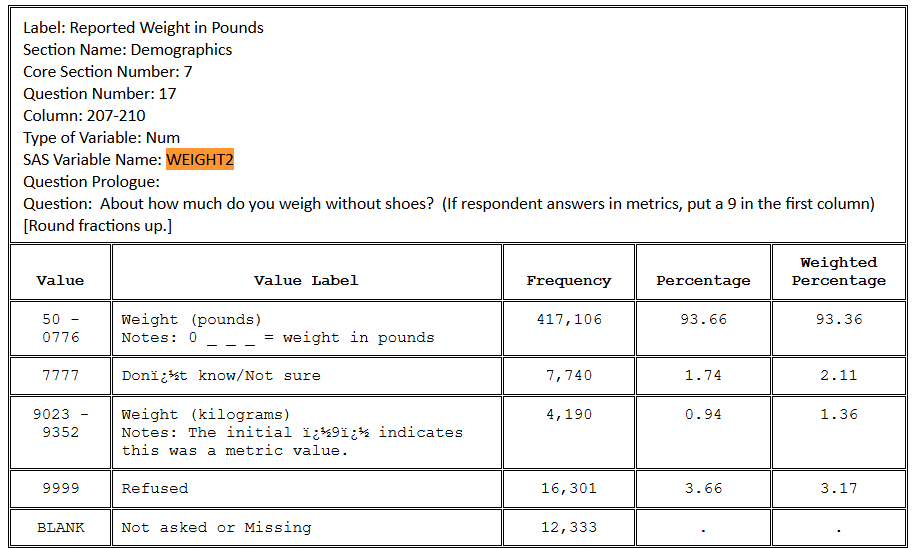

Some values in this column are vauge and does not make sense in analysis, we choose to replace them with median

In [50]:
#Fixing WEIGHT value format
mental_health_df['WEIGHT2'].value_counts()

WEIGHT2
200.0     22131
180.0     20305
150.0     17972
160.0     17747
170.0     16674
          ...  
9117.0        1
51.0          1
615.0         1
501.0         1
707.0         1
Name: count, Length: 631, dtype: int64

In [51]:
#

mental_health_df['WEIGHT2'] = mental_health_df['WEIGHT2'].replace([7777, 9999], np.nan)

mental_health_df.loc[mental_health_df['WEIGHT2'] >= 9000, 'WEIGHT2'] = np.nan

median_val = mental_health_df['WEIGHT2'].median()
mental_health_df['WEIGHT2'] = mental_health_df['WEIGHT2'].fillna(median_val)

mental_health_df['WEIGHT2'].describe()

count    457670.000000
mean        182.722538
std          45.151553
min          50.000000
25%         151.000000
50%         178.000000
75%         203.000000
max         776.000000
Name: WEIGHT2, dtype: float64

#### HEIGHT3  


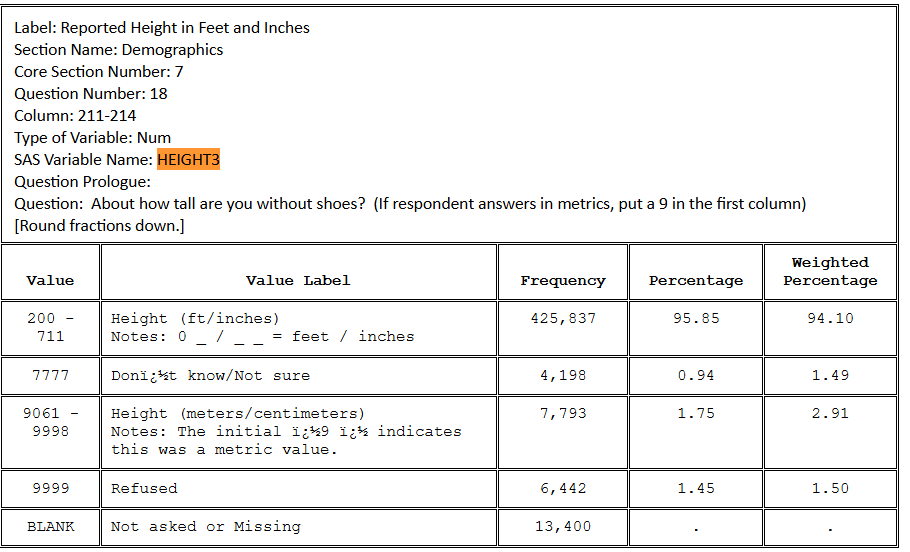

Some values in this column are vauge and does not make sense in analysis, we choose to replace them with median

In [52]:
mental_health_df['HEIGHT3'].value_counts()

HEIGHT3
506.0     37623
504.0     36081
507.0     34196
510.0     33137
505.0     33085
          ...  
9203.0        1
9098.0        1
9209.0        1
9134.0        1
9117.0        1
Name: count, Length: 173, dtype: int64

In [53]:
mental_health_df['HEIGHT3'] = mental_health_df['HEIGHT3'].replace([7777, 9999], np.nan)

mental_health_df.loc[mental_health_df['HEIGHT3'] >= 9000, 'HEIGHT3'] = np.nan

median_val = mental_health_df['HEIGHT3'].median()
mental_health_df['HEIGHT3'] = mental_health_df['HEIGHT3'].fillna(median_val)

mental_health_df['HEIGHT3'].describe()

count    457670.000000
mean        519.075546
std          37.594382
min         211.000000
25%         504.000000
50%         507.000000
75%         510.000000
max         800.000000
Name: HEIGHT3, dtype: float64

In [54]:
#We reformat to normal feet/ inches
mental_health_df['HEIGHT3'] = mental_health_df['HEIGHT3'] / 100

mental_health_df['HEIGHT3'].describe()

count    457670.000000
mean          5.190755
std           0.375944
min           2.110000
25%           5.040000
50%           5.070000
75%           5.100000
max           8.000000
Name: HEIGHT3, dtype: float64

#### DEAF  


In [55]:
#Fixing DEAF value format
mental_health_df['DEAF'].value_counts()

DEAF
2.0    399577
1.0     40990
7.0      1314
9.0       711
Name: count, dtype: int64

In [56]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DEAF' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['DEAF'] = mental_health_df['DEAF'].replace([7, 9], np.nan)

mode_val = mental_health_df['DEAF'].mode()[0]
mental_health_df['DEAF'] = mental_health_df['DEAF'].fillna(mode_val)

mental_health_df['DEAF'].value_counts()

DEAF
2.0    416680
1.0     40990
Name: count, dtype: int64

In [57]:
#change DEAF format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['DEAF'] = mental_health_df['DEAF'].replace({2: 0})
mental_health_df['DEAF'].value_counts()

DEAF
0.0    416680
1.0     40990
Name: count, dtype: int64

#### BLIND  


In [58]:
#Fixing BLIND value format
mental_health_df['BLIND'].value_counts()

BLIND
2.0    415197
1.0     24479
7.0      1128
9.0       618
Name: count, dtype: int64

In [59]:

#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DECIDE' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['BLIND'] = mental_health_df['BLIND'].replace([7, 9], np.nan)

median_val = mental_health_df['BLIND'].mode()[0]
mental_health_df['BLIND'] = mental_health_df['BLIND'].fillna(median_val)

mental_health_df['BLIND'].value_counts()

BLIND
2.0    433191
1.0     24479
Name: count, dtype: int64

In [60]:
#change BLIND format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['BLIND'] = mental_health_df['BLIND'].replace({2: 0})
mental_health_df['BLIND'].value_counts()

BLIND
0.0    433191
1.0     24479
Name: count, dtype: int64

#### DECIDE  


In [61]:
#Fixing DECIDE value format
mental_health_df['DECIDE'].value_counts()

DECIDE
2.0    383469
1.0     53689
7.0      2166
9.0       905
Name: count, dtype: int64

In [62]:
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DECIDE' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['DECIDE'] = mental_health_df['DECIDE'].replace([7, 9], np.nan)

median_val = mental_health_df['DECIDE'].mode()[0]
mental_health_df['DECIDE'] = mental_health_df['DECIDE'].fillna(median_val)

mental_health_df['DECIDE'].value_counts()

DECIDE
2.0    403981
1.0     53689
Name: count, dtype: int64

In [63]:
#change DECIDE format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['DECIDE'] = mental_health_df['DECIDE'].replace({2: 0})
mental_health_df['DECIDE'].value_counts()

DECIDE
0.0    403981
1.0     53689
Name: count, dtype: int64

#### DIFFWALK  


In [64]:
#Fixing DIFFWALK value format
mental_health_df['DIFFWALK'].value_counts()

DIFFWALK
2.0    365793
1.0     71425
7.0      1193
9.0       587
Name: count, dtype: int64

In [65]:

#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DECIDE' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['DIFFWALK'] = mental_health_df['DIFFWALK'].replace([7, 9], np.nan)

median_val = mental_health_df['DIFFWALK'].mode()[0]
mental_health_df['DIFFWALK'] = mental_health_df['DIFFWALK'].fillna(median_val)

mental_health_df['DIFFWALK'].value_counts()

DIFFWALK
2.0    386245
1.0     71425
Name: count, dtype: int64

In [66]:
#change DIFFWALK format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['DIFFWALK'] = mental_health_df['DIFFWALK'].replace({2: 0})
mental_health_df['DIFFWALK'].value_counts()

DIFFWALK
0.0    386245
1.0     71425
Name: count, dtype: int64

#### DIFFDRES  


In [67]:
#Fixing DIFFDRES value format
mental_health_df['DIFFDRES'].value_counts()

DIFFDRES
2.0    419552
1.0     17844
7.0       435
9.0       380
Name: count, dtype: int64

In [68]:

#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode
#Filling n/a value in 'DECIDE' with mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['DIFFDRES'] = mental_health_df['DIFFDRES'].replace([7, 9], np.nan)

median_val = mental_health_df['DIFFDRES'].mode()[0]
mental_health_df['DIFFDRES'] = mental_health_df['DIFFDRES'].fillna(median_val)

mental_health_df['DIFFDRES'].value_counts()

DIFFDRES
2.0    439826
1.0     17844
Name: count, dtype: int64

In [69]:
#change DIFFDRES format
#We make no as base value so we change 2 = no to 0 = no
mental_health_df['DIFFDRES'] = mental_health_df['DIFFDRES'].replace({2: 0})
mental_health_df['DIFFDRES'].value_counts()

DIFFDRES
0.0    439826
1.0     17844
Name: count, dtype: int64

#### DIFFALON

In [70]:
#Filling n/a value in 'DIFFALON' with mode
#Answer "Not sure"= 7, "Refused"= 9, "Not asked or Missing" = blank, we'll change this to mode

#Replace invalid value to N/A so we can make it into mode
mental_health_df['DIFFALON'] = mental_health_df['DIFFALON'].replace([7, 9], np.nan)

mode_val = mental_health_df['DIFFALON'].mode()[0]
mental_health_df['DIFFALON'] = mental_health_df['DIFFALON'].fillna(mode_val)

mental_health_df['DIFFALON'].value_counts()

DIFFALON
2.0    422627
1.0     35043
Name: count, dtype: int64

In [71]:
#change DIFFALON format
#original value 1 = yes, 2 = no. We make no as base value so we change 2 = no to 0 = no
mental_health_df['DIFFALON'] = mental_health_df['DIFFALON'].replace({2: 0})
mental_health_df['DIFFALON'].value_counts()

DIFFALON
0.0    422627
1.0     35043
Name: count, dtype: int64

#### _RACE  


In [72]:
mental_health_df['_RACE'] = mental_health_df['_RACE'].replace([9], np.nan)

median_val = mental_health_df['_RACE'].mode()[0]
mental_health_df['_RACE'] = mental_health_df['_RACE'].fillna(median_val)

#Makeing Hispanic =8 as baseline => Hispanic =0
mental_health_df['_RACE'] = mental_health_df['_RACE'].replace({8: 0})

mental_health_df['_RACE'].value_counts()

_RACE
1.0    338449
0.0     48646
2.0     35172
4.0     12646
7.0     10486
3.0      6460
6.0      3737
5.0      2074
Name: count, dtype: int64

#### _AGE_G  


In [73]:
mental_health_df['_AGE_G'].isnull().sum()

np.int64(0)

In [74]:
#Making Age 65 or older = 6 as baseline => Age 65 or older = 0
mental_health_df['_AGE_G'] = mental_health_df['_AGE_G'].replace({6: 0})

#### _URBSTAT  


In [75]:

# 1. Recode 2 to 0 (Rural to 0, Urban stays 1)
mental_health_df['_URBSTAT'] = mental_health_df['_URBSTAT'].replace({2: 0})

# 2. Identify "9" as missing (Turn 9 into NaN)

mental_health_df['_URBSTAT'] = mental_health_df['_URBSTAT'].replace({9: np.nan})

# 3.mode calculation
#
mode_val = mental_health_df['_URBSTAT'].mode()[0]

# 4. Filling gaps
mental_health_df['_URBSTAT'] = mental_health_df['_URBSTAT'].fillna(mode_val)

# 5. Verify
mental_health_df['_URBSTAT'].value_counts()

_URBSTAT
1.0    397876
0.0     59794
Name: count, dtype: int64

#### _HLTHPL2  


In [76]:

# 1. Recode 2 to 0 (No becomes 0, Yes stays 1)
mental_health_df['_HLTHPL2'] = mental_health_df['_HLTHPL2'].replace({2: 0})

# 2. Identify "9" as missing (Turn 9 into NaN)

mental_health_df['_HLTHPL2'] = mental_health_df['_HLTHPL2'].replace({9: np.nan})

# 3. Calculate the mode (The most frequent health plan status)
hp_mode = mental_health_df['_HLTHPL2'].mode()[0]

# 4. Fill the 9s (now NaNs) with the mode
mental_health_df['_HLTHPL2'] = mental_health_df['_HLTHPL2'].fillna(hp_mode)

# 5. Verify the final counts
print(f"The mode used for filling was: {hp_mode}")
mental_health_df['_HLTHPL2'].value_counts()

The mode used for filling was: 1.0


_HLTHPL2
1.0    432264
0.0     25406
Name: count, dtype: int64

#### _SMOKER3  


In [77]:
# 1. Identify "9" as missing and turn into NaN
mental_health_df['_SMOKER3'] = mental_health_df['_SMOKER3'].replace({9: np.nan})

# 2. Calculate the mode (The most frequent smoking status)
smoker_mode = mental_health_df['_SMOKER3'].mode()[0]

# 3. Fill the NaNs with that mode
mental_health_df['_SMOKER3'] = mental_health_df['_SMOKER3'].fillna(smoker_mode)

#4 We change Never smoked =4 to 0, making it as baseline

mental_health_df['_SMOKER3'] = mental_health_df['_SMOKER3'].replace({4: 0})

# 5. Verify the distribution
print(f"The mode used for filling was: {smoker_mode}")
mental_health_df['_SMOKER3'].value_counts()

The mode used for filling was: 4.0


_SMOKER3
0.0    290978
3.0    119598
1.0     33118
2.0     13976
Name: count, dtype: int64

#### _RFDRHV9  


In [78]:

# 1. Recode the values:
# Original: 1 (No), 2 (Yes)
# Goal: 0 (No), 1 (Yes)
mental_health_df['_RFDRHV9'] = mental_health_df['_RFDRHV9'].replace({1: 0, 2: 1})

# 2. Identify "9" as missing (Turn 9 into NaN)
mental_health_df['_RFDRHV9'] = mental_health_df['_RFDRHV9'].replace({9: np.nan})

# 3. Calculate the mode
alcohol_mode = mental_health_df['_RFDRHV9'].mode()[0]

# 4. Fill the NaNs with  mode
mental_health_df['_RFDRHV9'] = mental_health_df['_RFDRHV9'].fillna(alcohol_mode)

# 5. Verify
print(f"The mode used for filling was: {alcohol_mode}")
mental_health_df['_RFDRHV9'].value_counts()

The mode used for filling was: 0.0


_RFDRHV9
0.0    433510
1.0     24160
Name: count, dtype: int64

### Handling duplicates

In [79]:
num_duplicates = df.duplicated().sum()
print(f"🔁 Number of duplicate rows: {num_duplicates}")

🔁 Number of duplicate rows: 0


## **6. EDA (Exploratory Data Analysis)**

| **Feature** | **Description**                                            |
| ----------- | ---------------------------------------------------------- |
| _SEX        | Sex of respondent (Male/Female)                            |
| PHYSHLTH    | Number of days physical health was not good (past 30 days) |
| MENTHLTH    | Number of days mental health was not good (past 30 days)   |
| MEDCOST1    | Could not see a doctor due to cost (1=Yes, 2=No)           |
| EXERANY2    | Exercised in the past 30 days (1=Yes, 2=No)                |
| ADDEPEV3    | Ever diagnosed with a depressive disorder (1=Yes, 2=No)    |
| MARITAL     | Marital status                                             |
| EDUCA       | Education level                                            |
| RENTHOM1    | Own or rent home                                           |
| VETERAN3    | Veteran status                                             |
| EMPLOY1     | Employment status                                          |
| CHILDREN    | Number of children in household                            |
| INCOME3     | Income level                                               |
| WEIGHT2     | Reported weight                                            |
| HEIGHT3     | Reported height                                            |
| DEAF        | Serious difficulty hearing (1=Yes, 2=No)                   |
| BLIND       | Serious difficulty seeing (1=Yes, 2=No)                    |
| DECIDE      | Difficulty concentrating or remembering                    |
| DIFFWALK    | Difficulty walking or climbing stairs                      |
| DIFFDRES    | Difficulty dressing or bathing                             |
| DIFFALON    | Difficulty doing errands alone                             |
| _RACE       | Race/ethnicity category                                    |
| _AGE_G      | Age group                                                  |
| _URBSTAT    | Urban or rural residence                                   |
| _HLTHPL2    | Health insurance coverage                                  |
| _SMOKER3    | Smoking status                                             |
| _RFDRHV9    | Heavy drinking indicator                                   |


In [80]:
'''
We used knowledge from preivous class
'''


# exploring bivariate relationships with updated variables

selected_cols = ['PHYSHLTH','CHILDREN',
       'WEIGHT2', 'HEIGHT3','MENTHLTH']

correlation_matrix = mental_health_df[selected_cols].corr()

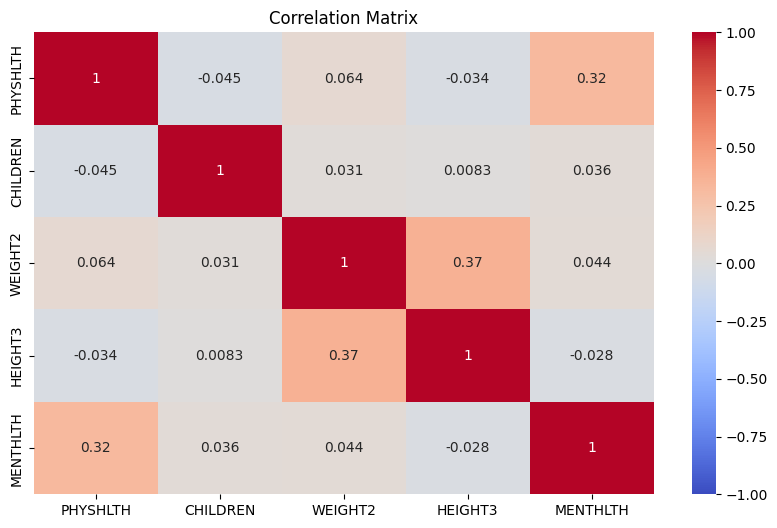

In [81]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

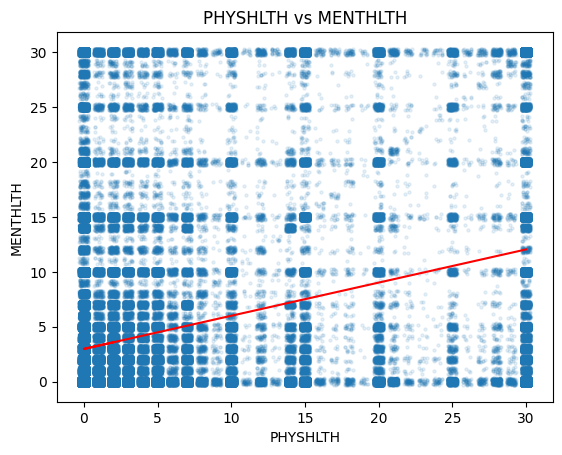

In [82]:
jitter = 0.3
x = mental_health_df['PHYSHLTH'] + np.random.uniform(-jitter, jitter, size=len(mental_health_df))
y = mental_health_df['MENTHLTH'] + np.random.uniform(-jitter, jitter, size=len(mental_health_df))

plt.scatter(x, y, alpha=0.1, s=5)
plt.xlabel('PHYSHLTH')
plt.ylabel('MENTHLTH')
plt.title('PHYSHLTH vs MENTHLTH')

m, b = np.polyfit(mental_health_df['PHYSHLTH'], mental_health_df['MENTHLTH'], 1)
plt.plot(mental_health_df['PHYSHLTH'], m * mental_health_df['PHYSHLTH'] + b, color='red')

plt.show()

Because 'PHYSHLTH' and 'MENTHLTH' all are discrete values and have the same range from 0 to 30 days, so we use jiter to make overlapping dots more visible, and dense areas appear darker

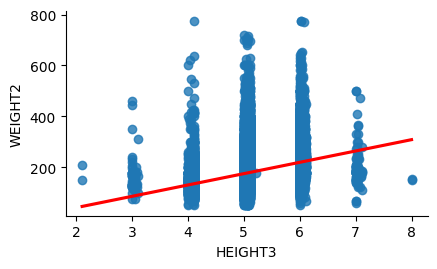

In [83]:
sns.lmplot(
    data=mental_health_df,
    x='HEIGHT3',
    y='WEIGHT2',
    line_kws={'color': 'red'},
    height=2.8,
    aspect=1.6,
    ci=None
)
plt.show()

In [84]:
# Decode HEIGHT3 (now in format 5.04 = 5'4")
height_ft = (mental_health_df['HEIGHT3'] // 1).astype(float)
height_in = ((mental_health_df['HEIGHT3'] % 1) * 100).round().astype(float)
height_m = (height_ft * 12 + height_in) * 0.0254

# Decode WEIGHT2 (in pounds)
weight_kg = mental_health_df['WEIGHT2'] * 0.453592

# Calculate BMI
mental_health_df['BMI'] = weight_kg / (height_m ** 2)

# Remove unrealistic BMI values
mental_health_df['BMI'] = mental_health_df['BMI'].apply(lambda x: x if 10 < x < 80 else np.nan)
mental_health_df['BMI'] = mental_health_df['BMI'].fillna(mental_health_df['BMI'].median())

mental_health_df['BMI'].describe()

count    457670.000000
mean         28.497480
std           6.247635
min          10.043843
25%          24.373059
50%          27.878432
75%          31.411530
max          79.876407
Name: BMI, dtype: float64

In [85]:
# exploring bivariate relationships with updated variables

selected_cols = ['PHYSHLTH','CHILDREN',
       'WEIGHT2', 'BMI', 'HEIGHT3','MENTHLTH']

correlation_matrix = mental_health_df[selected_cols].corr()

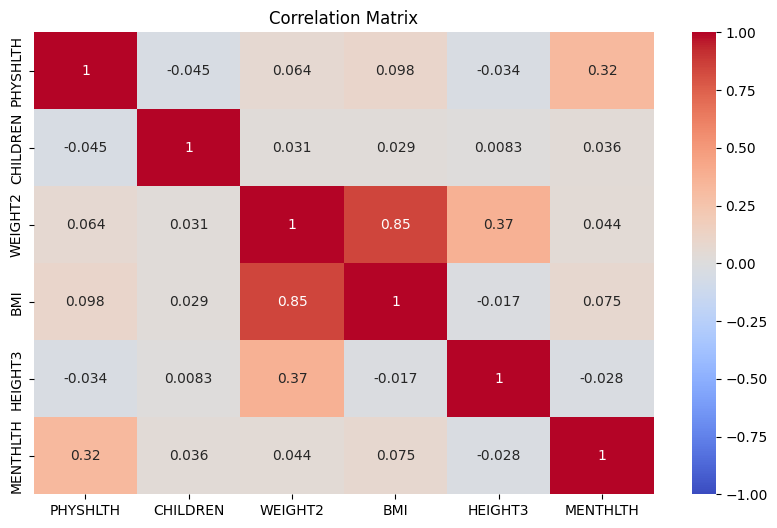

In [86]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

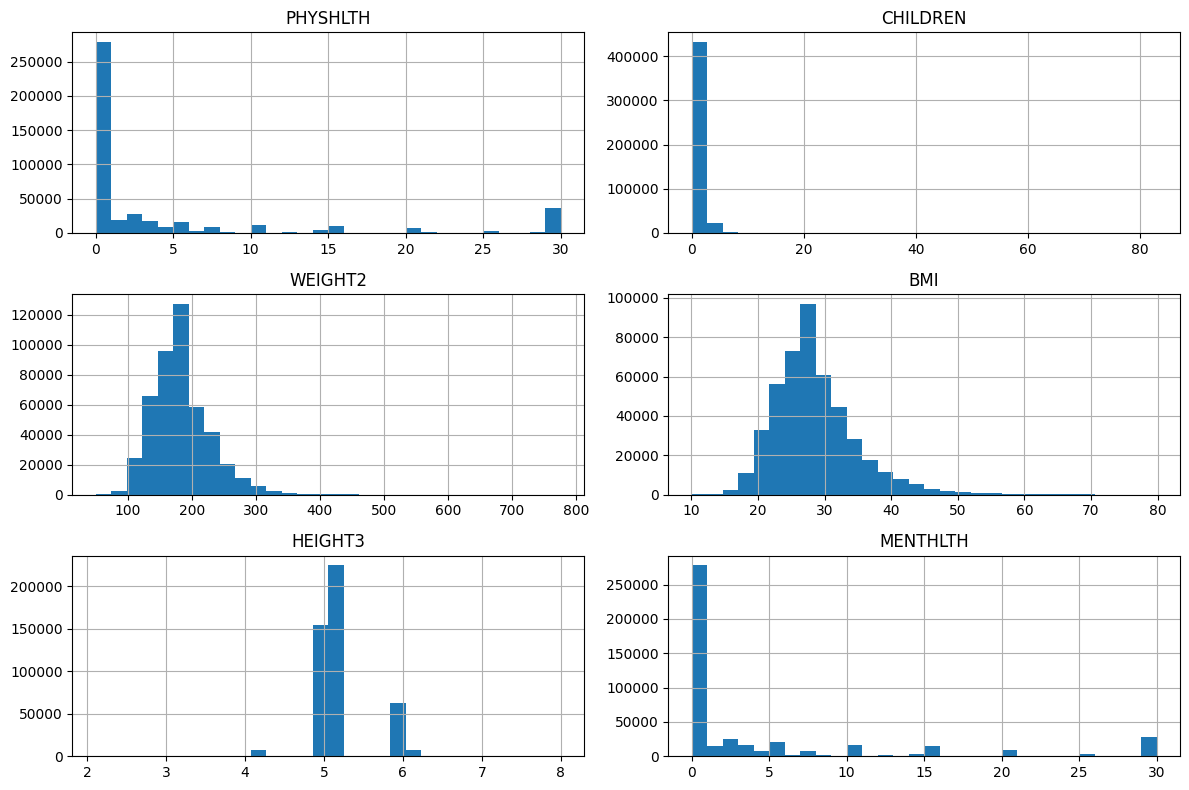

In [87]:
#Distribution of Continuous Variables Histograms (overall distribution)
import matplotlib.pyplot as plt

mental_health_df[selected_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

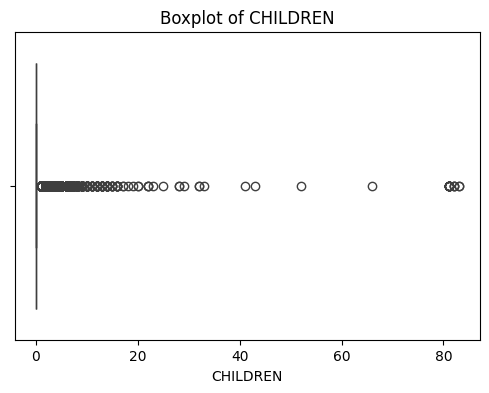

In [88]:
plt.figure(figsize=(6,4))
sns.boxplot(x=mental_health_df['CHILDREN'])
plt.title('Boxplot of CHILDREN')
plt.show()

In [89]:
mental_health_df['CHILDREN'].value_counts().sort_values(ascending = False)

CHILDREN
0     345679
1      48206
2      38838
3      16120
4       5672
5       1854
6        695
7        292
8        127
9         62
10        25
12        18
14        13
81        12
13        11
11         8
16         7
15         5
82         3
22         3
17         2
32         2
83         2
20         2
28         2
18         1
52         1
19         1
66         1
29         1
25         1
41         1
33         1
43         1
23         1
Name: count, dtype: int64

In [90]:
mental_health_df = mental_health_df[mental_health_df['HEIGHT3'] <= 10]

In [91]:
mental_health_df['CHILDREN'].describe()

count    457670.000000
mean          0.474243
std           1.127831
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          83.000000
Name: CHILDREN, dtype: float64

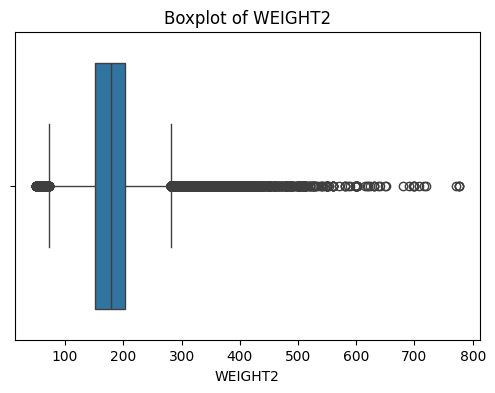

In [92]:
# plot weight on its own, physhealth anf children and ment helath then height on its own

plt.figure(figsize=(6,4))
sns.boxplot(x=mental_health_df['WEIGHT2'])
plt.title('Boxplot of WEIGHT2')
plt.show()

In [93]:
mental_health_df['WEIGHT2'].describe()

count    457670.000000
mean        182.722538
std          45.151553
min          50.000000
25%         151.000000
50%         178.000000
75%         203.000000
max         776.000000
Name: WEIGHT2, dtype: float64

There are outliers seen in the datset but those are in acceptable range (50 - 776) in dataset, so we will keep it

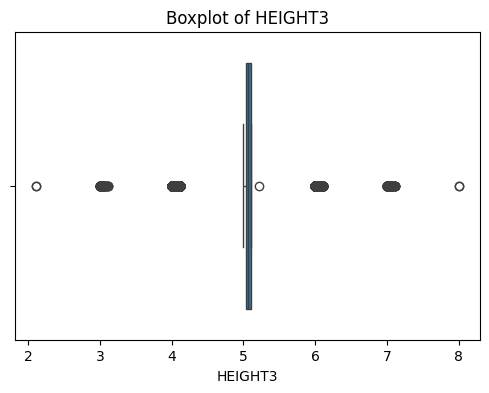

In [94]:
plt.figure(figsize=(6,4))
sns.boxplot(x=mental_health_df['HEIGHT3'])
plt.title('Boxplot of HEIGHT3')
plt.show()

We have the allowable range 200 - 711. there are values seen to surpass the range, so we remove them

In [95]:
mental_health_df = mental_health_df[mental_health_df['HEIGHT3'] <= 7.11]

In [96]:
mental_health_df['HEIGHT3'].describe()

count    457668.000000
mean          5.190743
std           0.375899
min           2.110000
25%           5.040000
50%           5.070000
75%           5.100000
max           7.110000
Name: HEIGHT3, dtype: float64

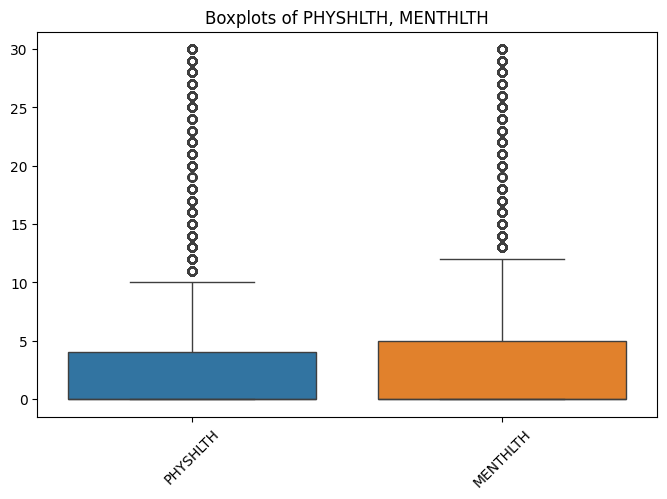

In [97]:
cols = ['PHYSHLTH', 'MENTHLTH']

plt.figure(figsize=(8,5))
sns.boxplot(data=mental_health_df[cols])
plt.title('Boxplots of PHYSHLTH, MENTHLTH')
plt.xticks(rotation=45)
plt.show()

In [98]:
mental_health_df[cols].describe()

,PHYSHLTH,MENTHLTH
count,457668.000000,457668.000000
mean,4.496921,4.336036
std,8.849392,8.306037
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,4.000000,5.000000
max,30.000000,30.000000


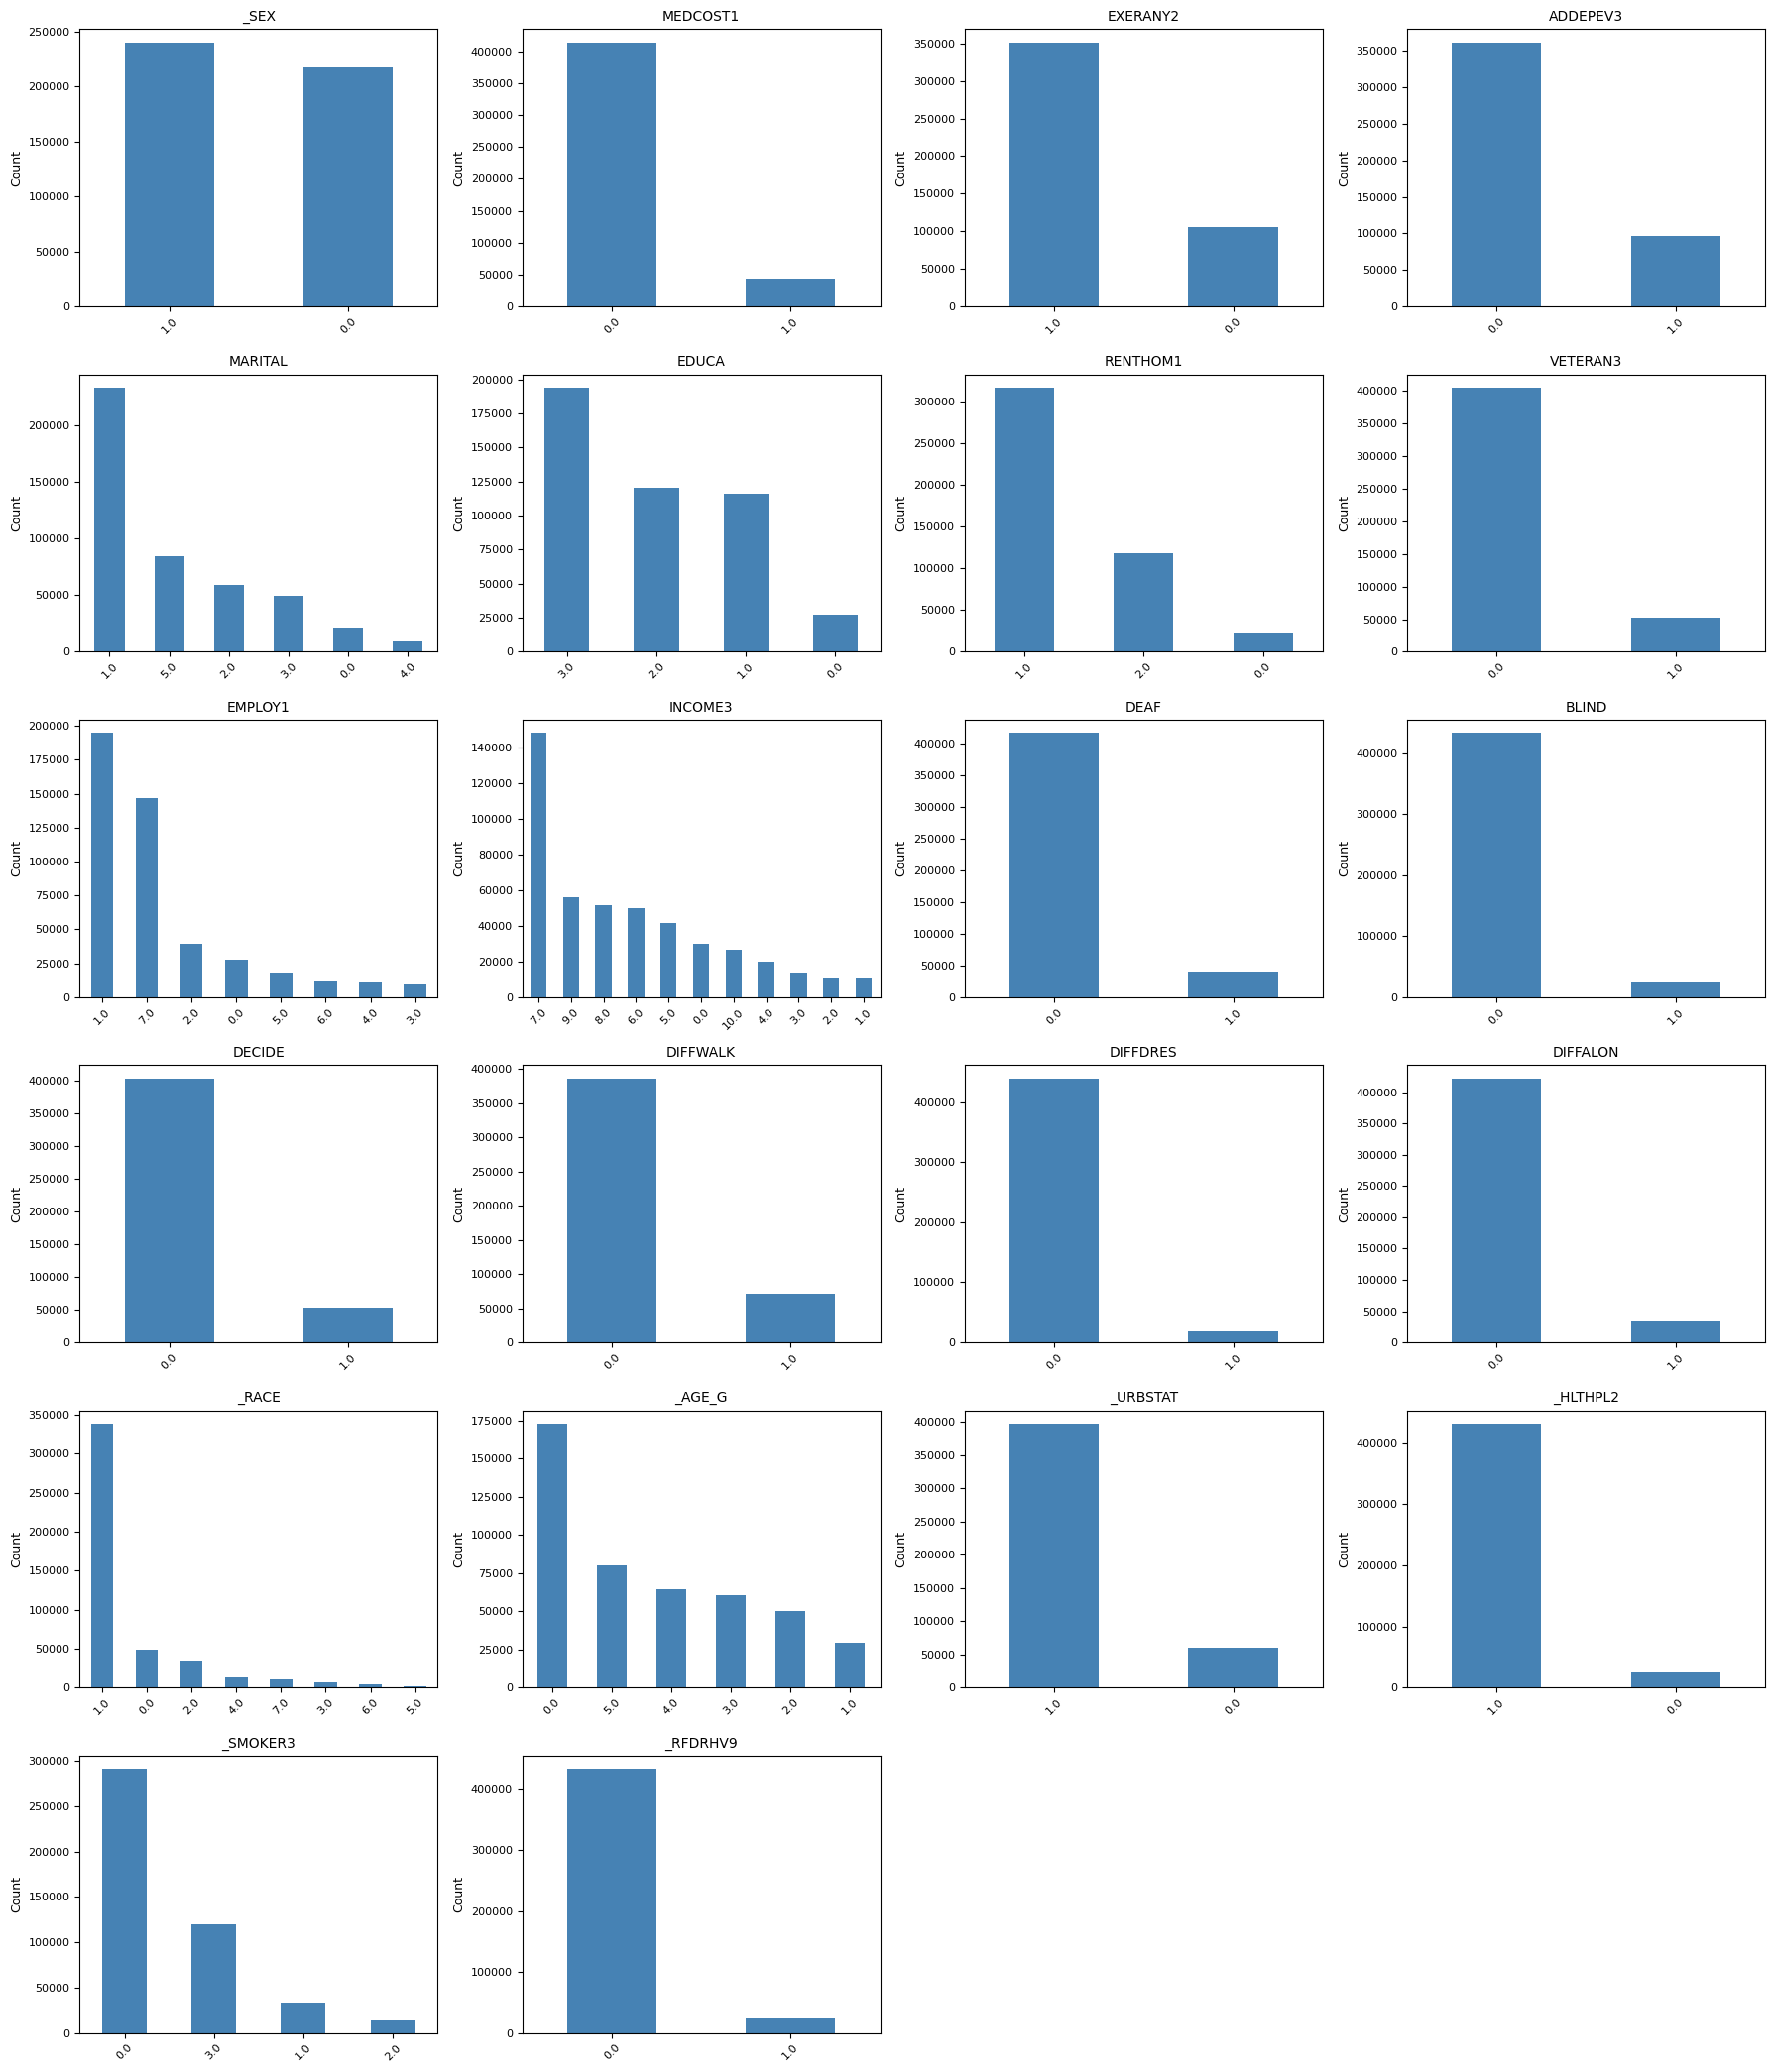

In [99]:
#We used AI to help us with making graph more presentable
cat_cols = [col for col in mental_health_df.columns if mental_health_df[col].nunique() <= 11]

# Grid setup
n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = axes.flatten()

# Loop and plot
for i, col in enumerate(cat_cols):
    mental_health_df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=9)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [100]:
mental_health_df.columns

Index(['_SEX', 'PHYSHLTH', 'MENTHLTH', 'MEDCOST1', 'EXERANY2', 'ADDEPEV3',
       'MARITAL', 'EDUCA', 'RENTHOM1', 'VETERAN3', 'EMPLOY1', 'CHILDREN',
       'INCOME3', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK',
       'DIFFDRES', 'DIFFALON', '_RACE', '_AGE_G', '_URBSTAT', '_HLTHPL2',
       '_SMOKER3', '_RFDRHV9', 'BMI'],
      dtype='object')

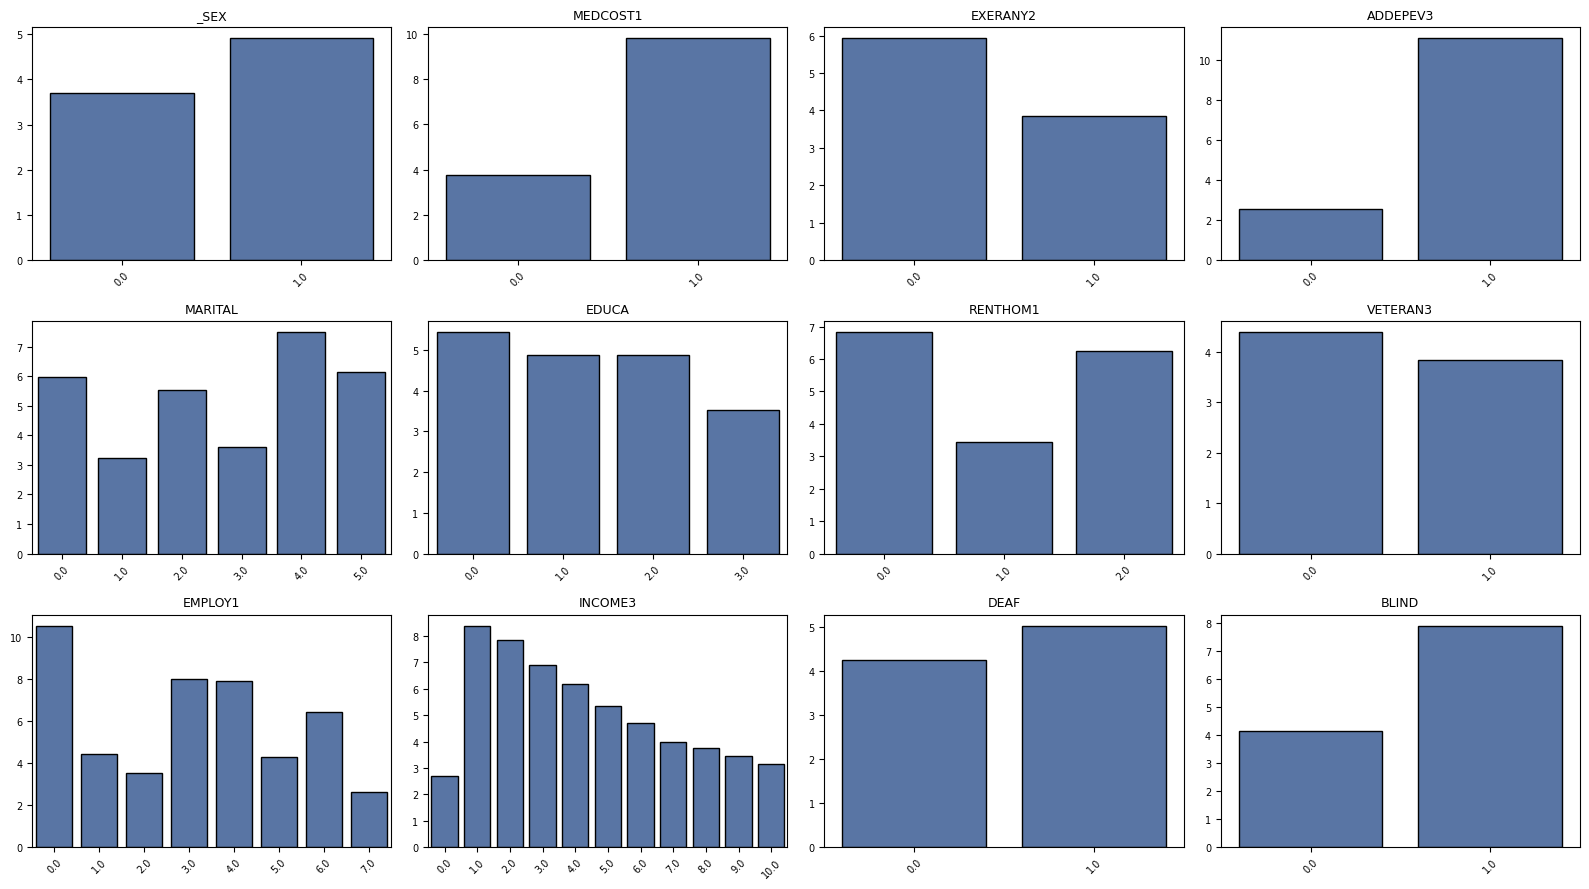

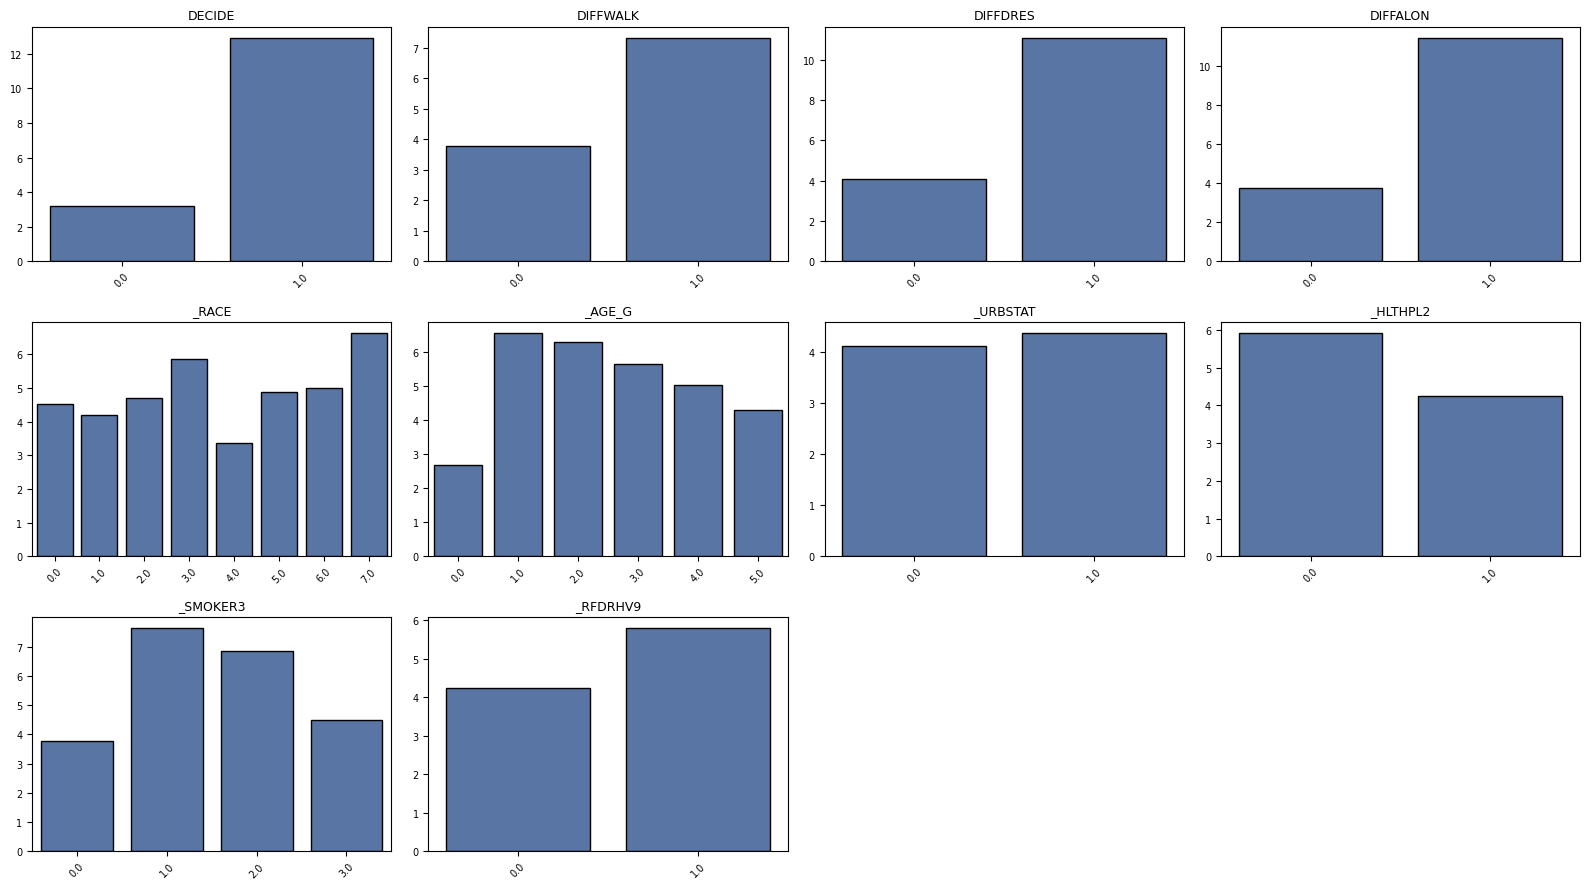

In [101]:
plots_per_fig = 12

for start in range(0, len(cat_cols), plots_per_fig):
    subset = cat_cols[start:start + plots_per_fig]
    n_cols = 4
    n_rows = int(np.ceil(len(subset) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        sns.barplot(
            data=mental_health_df,
            x=col,
            y='MENTHLTH',
            estimator='mean',
            errorbar=None,
            ax=axes[i],
            color='#4C72B0',   
            edgecolor='black'
        )

        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=7)
        axes[i].tick_params(axis='y', labelsize=7)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Variables that have significant different means within its groups

- DECIDE
- _SMOKER3
- _AGE_G
- MARITAL
- INCOME3
- MEDCOST1
- RENTHOM1
- _URBSTAT
- _HLTHPL2
- _RFDRHV9
- Almost aLL Variables that relates to disability (BLIND, DIFFWALK, DIFFDRES, DIFFALON)

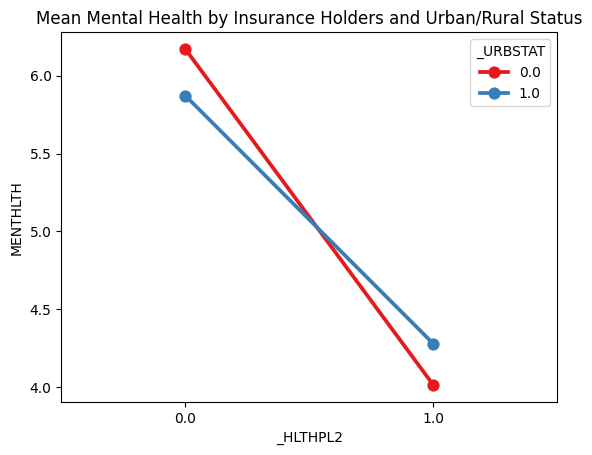

In [102]:
 #Interaction-style plots 
sns.pointplot(x='_HLTHPL2', y='MENTHLTH', hue='_URBSTAT', data=mental_health_df, palette='Set1', errorbar=None)
plt.title('Mean Mental Health by Insurance Holders and Urban/Rural Status')
plt.show()

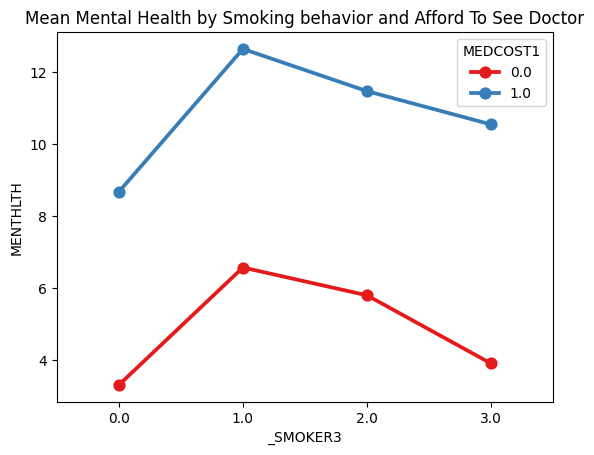

In [103]:
 #Interaction-style plots 
sns.pointplot(x='_SMOKER3', y='MENTHLTH', hue='MEDCOST1', data=mental_health_df, palette='Set1', errorbar=None)
plt.title('Mean Mental Health by Smoking behavior and Afford To See Doctor')
plt.show()

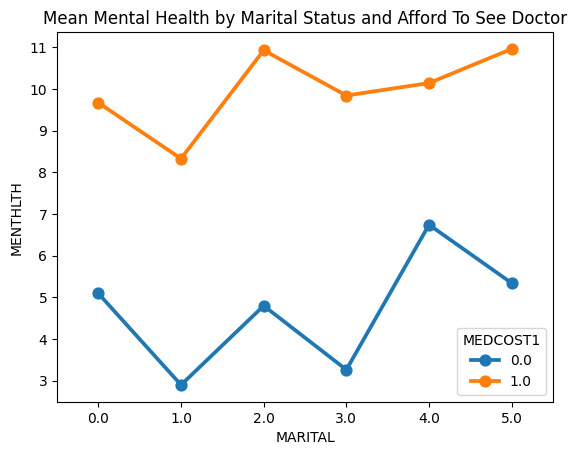

In [104]:
 #Interaction-style plots 
sns.pointplot(x='MARITAL', y='MENTHLTH', hue='MEDCOST1', data=mental_health_df, errorbar=None)
plt.title('Mean Mental Health by Marital Status and Afford To See Doctor')
plt.show()

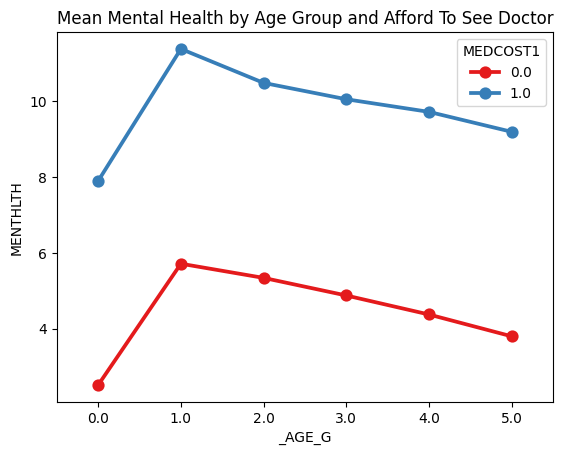

In [105]:
 #Interaction-style plots 
sns.pointplot(x='_AGE_G', y='MENTHLTH', hue='MEDCOST1', data=mental_health_df, palette='Set1', errorbar=None)
plt.title('Mean Mental Health by Age Group and Afford To See Doctor')
plt.show()

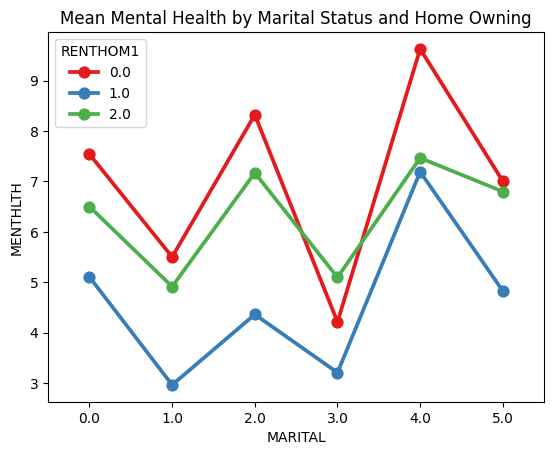

In [106]:
 #Interaction-style plots 
sns.pointplot(x='MARITAL', y='MENTHLTH', hue='RENTHOM1', data=mental_health_df, palette='Set1', errorbar=None)
plt.title('Mean Mental Health by Marital Status and Home Owning')
plt.show()

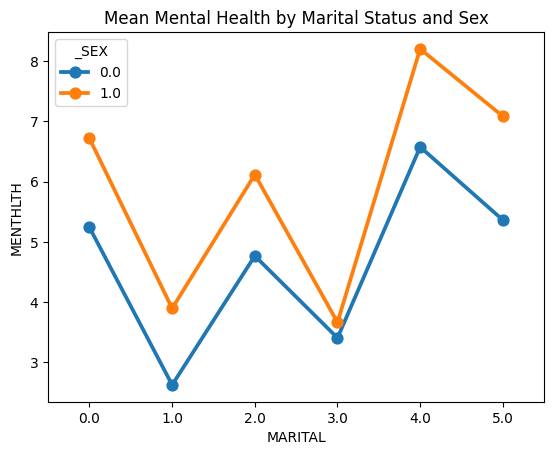

In [107]:
 #Interaction-style plots 
sns.pointplot(x='MARITAL', y='MENTHLTH', hue='_SEX', data=mental_health_df, errorbar=None)
plt.title('Mean Mental Health by Marital Status and Sex')
plt.show()

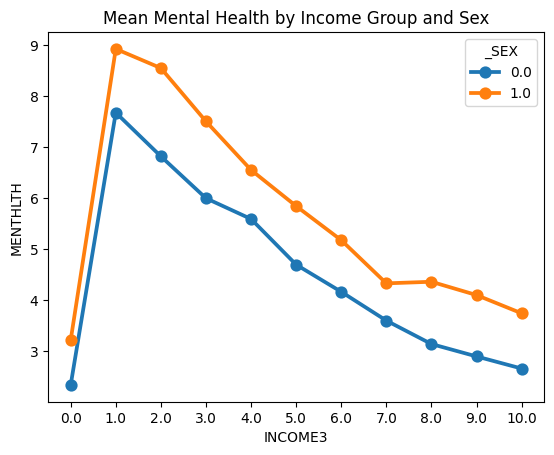

In [108]:
 #Interaction-style plots 
sns.pointplot(x='INCOME3', y='MENTHLTH', hue='_SEX', data=mental_health_df, errorbar=None)
plt.title('Mean Mental Health by Income Group and Sex')
plt.show()

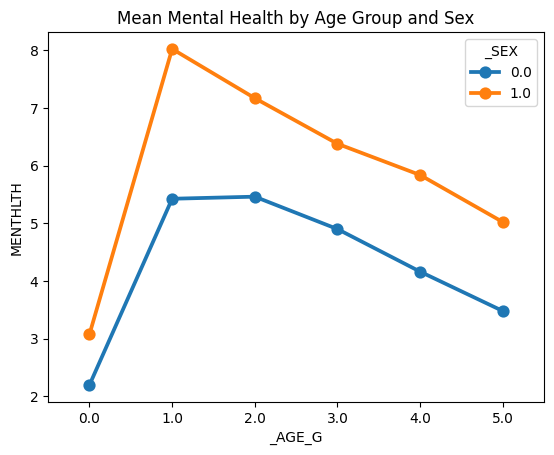

In [109]:
 #Difference in Mean Mental Health Between Sex Across Age Groups plot
sns.pointplot(x='_AGE_G', y='MENTHLTH', hue='_SEX', data=mental_health_df, errorbar=None)
plt.title('Mean Mental Health by Age Group and Sex')
plt.show()

## **7. Feature engineering**

In [110]:
#BMI is not well correlated to 'MENTHLTH' so we drop it
mental_health_df = mental_health_df.drop(columns=['BMI'])
mental_health_df

,_SEX,PHYSHLTH,MENTHLTH,MEDCOST1,EXERANY2,ADDEPEV3,MARITAL,EDUCA,RENTHOM1,VETERAN3,...,DECIDE,DIFFWALK,DIFFDRES,DIFFALON,_RACE,_AGE_G,_URBSTAT,_HLTHPL2,_SMOKER3,_RFDRHV9
0,1.0,2.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,0.0
2,0.0,30.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,5.0,1.0,1.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,4.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,0.0,0.0,2.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0
457666,0.0,5.0,1.0,0.0,0.0,0.0,5.0,0.0,2.0,0.0,...,1.0,0.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,1.0
457667,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0
457668,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0,3.0,0.0


In [111]:
# Scenario A: Use `frequent_distress` as Y (classification)

mental_health_df_A = mental_health_df.copy()

mental_health_df_A.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457668 entries, 0 to 457669
Data columns (total 27 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _SEX      457668 non-null  float64
 1   PHYSHLTH  457668 non-null  float64
 2   MENTHLTH  457668 non-null  float64
 3   MEDCOST1  457668 non-null  float64
 4   EXERANY2  457668 non-null  float64
 5   ADDEPEV3  457668 non-null  float64
 6   MARITAL   457668 non-null  float64
 7   EDUCA     457668 non-null  float64
 8   RENTHOM1  457668 non-null  float64
 9   VETERAN3  457668 non-null  float64
 10  EMPLOY1   457668 non-null  float64
 11  CHILDREN  457668 non-null  int64  
 12  INCOME3   457668 non-null  float64
 13  WEIGHT2   457668 non-null  float64
 14  HEIGHT3   457668 non-null  float64
 15  DEAF      457668 non-null  float64
 16  BLIND     457668 non-null  float64
 17  DECIDE    457668 non-null  float64
 18  DIFFWALK  457668 non-null  float64
 19  DIFFDRES  457668 non-null  float64
 20  DIFFALON 

In [112]:
# 1 = frequent distress (14 or more bad mental health days)
# 0 = infrequent distress

mental_health_df_A['frequent_distress'] = (mental_health_df_A['MENTHLTH'] >= 14).astype(int)

mental_health_df_A = mental_health_df_A.drop(columns=['MENTHLTH'])

In [113]:
mental_health_df_A.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457668 entries, 0 to 457669
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _SEX               457668 non-null  float64
 1   PHYSHLTH           457668 non-null  float64
 2   MEDCOST1           457668 non-null  float64
 3   EXERANY2           457668 non-null  float64
 4   ADDEPEV3           457668 non-null  float64
 5   MARITAL            457668 non-null  float64
 6   EDUCA              457668 non-null  float64
 7   RENTHOM1           457668 non-null  float64
 8   VETERAN3           457668 non-null  float64
 9   EMPLOY1            457668 non-null  float64
 10  CHILDREN           457668 non-null  int64  
 11  INCOME3            457668 non-null  float64
 12  WEIGHT2            457668 non-null  float64
 13  HEIGHT3            457668 non-null  float64
 14  DEAF               457668 non-null  float64
 15  BLIND              457668 non-null  float64
 16  DECIDE 

In [114]:
mental_health_df_A['frequent_distress'].value_counts()

frequent_distress
0    395353
1     62315
Name: count, dtype: int64

In [115]:
#Define X and Y in Scenario A

X_A = mental_health_df_A.drop(columns=['frequent_distress'])
y_A = mental_health_df_A['frequent_distress']

In [116]:
# Scenario B: Use `MENTHLTH` as Y directly (regression)

mental_health_df_B = mental_health_df.copy()

mental_health_df_B.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457668 entries, 0 to 457669
Data columns (total 27 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _SEX      457668 non-null  float64
 1   PHYSHLTH  457668 non-null  float64
 2   MENTHLTH  457668 non-null  float64
 3   MEDCOST1  457668 non-null  float64
 4   EXERANY2  457668 non-null  float64
 5   ADDEPEV3  457668 non-null  float64
 6   MARITAL   457668 non-null  float64
 7   EDUCA     457668 non-null  float64
 8   RENTHOM1  457668 non-null  float64
 9   VETERAN3  457668 non-null  float64
 10  EMPLOY1   457668 non-null  float64
 11  CHILDREN  457668 non-null  int64  
 12  INCOME3   457668 non-null  float64
 13  WEIGHT2   457668 non-null  float64
 14  HEIGHT3   457668 non-null  float64
 15  DEAF      457668 non-null  float64
 16  BLIND     457668 non-null  float64
 17  DECIDE    457668 non-null  float64
 18  DIFFWALK  457668 non-null  float64
 19  DIFFDRES  457668 non-null  float64
 20  DIFFALON 

In [117]:
#Define X and Y in Scenario B

X_B = mental_health_df_B.drop(columns=['MENTHLTH'])
y_B = mental_health_df_B['MENTHLTH']

## **8. Train/Test Split**


In [118]:
SEED = 42

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
# Scenario A (Classification)
X_train_A, X_test_A, y_train_A, y_test_A = model_selection.train_test_split(X_A, y_A, random_state= SEED, stratify=y_A)

# Scenario B (Regression)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.20, random_state=SEED)

## **9. Fit the Model**

Recall is generally more important than precision, particularly for screening or diagnosing serious conditions. High recall ensures that nearly all actual positive cases are identified, minimizing dangerous false negatives (e.g., missing a cancer diagnosis).

https://medium.com/@venkatanaveen.avvaru/why-healthcare-ai-must-prioritize-recall-over-precision-fad1ec220d26

### LDA / QDA (For Scenario A)

In [121]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

LDA priors:
[0.86384308 0.13615692]

LDA class means:
[[5.13225301e-01 3.47458982e+00 7.23841964e-02 7.85427381e-01
  1.50336408e-01 2.03882434e+00 2.08357419e+00 1.19340337e+00
  1.15680488e-01 3.45725174e+00 4.63335750e-01 6.35737484e+00
  1.82037526e+02 5.19478367e+00 8.61170598e-02 4.49049795e-02
  7.34364197e-02 1.35446773e-01 2.72971013e-02 5.26617540e-02
  1.26584490e+00 2.06764919e+00 8.68866668e-01 9.48444429e-01
  8.93600661e-01 4.97175522e-02]
 [5.96670661e-01 1.10033379e+01 2.35129237e-01 6.59427422e-01
  5.89780897e-01 2.47363916e+00 1.85409534e+00 1.30849880e+00
  1.05956864e-01 2.58657138e+00 5.46687778e-01 5.87827371e+00
  1.87435895e+02 5.16929177e+00 1.10172030e-01 1.06534577e-01
  3.97381034e-01 2.87422972e-01 1.11134885e-01 2.28153886e-01
  1.35961571e+00 2.47772595e+00 8.73416638e-01 9.19740671e-01
  1.07499572e+00 7.15508388e-02]]


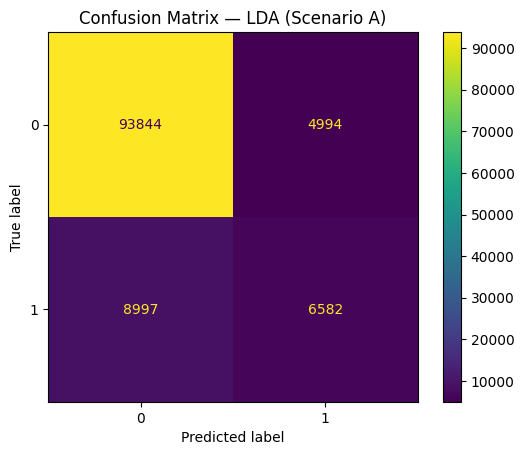

              precision    recall  f1-score   support

           0      0.913     0.949     0.931     98838
           1      0.569     0.422     0.485     15579

    accuracy                          0.878    114417
   macro avg      0.741     0.686     0.708    114417
weighted avg      0.866     0.878     0.870    114417



In [122]:
# LDA 

lda = LinearDiscriminantAnalysis()
model_lda = lda.fit(X_train_A, y_train_A)

print("LDA priors:")
print(model_lda.priors_)

print("\nLDA class means:")
print(model_lda.means_)

pred_lda = model_lda.predict(X_test_A)

cm_lda = confusion_matrix(y_test_A, pred_lda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda)
disp.plot()
plt.title("Confusion Matrix — LDA (Scenario A)")
plt.show()

print(classification_report(y_test_A, pred_lda, digits=3))

QDA priors:
[0.86384308 0.13615692]

QDA class means:
[[5.13225301e-01 3.47458982e+00 7.23841964e-02 7.85427381e-01
  1.50336408e-01 2.03882434e+00 2.08357419e+00 1.19340337e+00
  1.15680488e-01 3.45725174e+00 4.63335750e-01 6.35737484e+00
  1.82037526e+02 5.19478367e+00 8.61170598e-02 4.49049795e-02
  7.34364197e-02 1.35446773e-01 2.72971013e-02 5.26617540e-02
  1.26584490e+00 2.06764919e+00 8.68866668e-01 9.48444429e-01
  8.93600661e-01 4.97175522e-02]
 [5.96670661e-01 1.10033379e+01 2.35129237e-01 6.59427422e-01
  5.89780897e-01 2.47363916e+00 1.85409534e+00 1.30849880e+00
  1.05956864e-01 2.58657138e+00 5.46687778e-01 5.87827371e+00
  1.87435895e+02 5.16929177e+00 1.10172030e-01 1.06534577e-01
  3.97381034e-01 2.87422972e-01 1.11134885e-01 2.28153886e-01
  1.35961571e+00 2.47772595e+00 8.73416638e-01 9.19740671e-01
  1.07499572e+00 7.15508388e-02]]


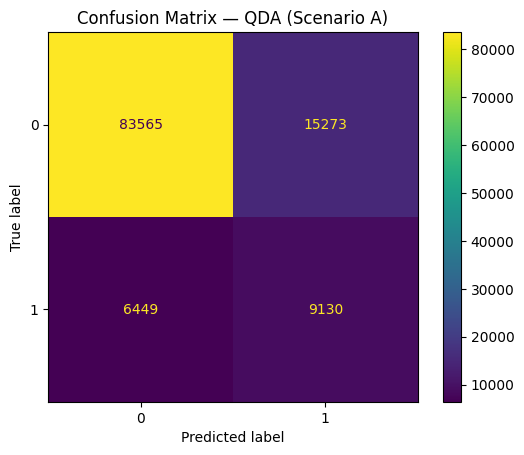

              precision    recall  f1-score   support

           0      0.928     0.845     0.885     98838
           1      0.374     0.586     0.457     15579

    accuracy                          0.810    114417
   macro avg      0.651     0.716     0.671    114417
weighted avg      0.853     0.810     0.827    114417



In [123]:
# QDA 

qda = QuadraticDiscriminantAnalysis()
model_qda = qda.fit(X_train_A, y_train_A)

print("QDA priors:")
print(model_qda.priors_)

print("\nQDA class means:")
print(model_qda.means_)

pred_qda = model_qda.predict(X_test_A)

cm_qda = confusion_matrix(y_test_A, pred_qda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda)
disp.plot()
plt.title("Confusion Matrix — QDA (Scenario A)")
plt.show()

print(classification_report(y_test_A, pred_qda, digits=3))

Since we have a very imbalanced dataset, and the class 1 recall is better in QDA (0.586) than LDA (0.422), choosing QDA is more reasonable.

### Logistic regression (For Scenario A)

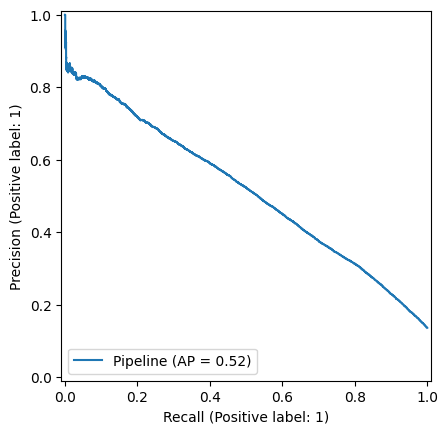

In [124]:
'''
The code are the same with week 5, but we wanted to prevent data leakage so we optimized it by using pipeline
through AI.
'''

# PR curve pattern — Scenario A
from sklearn.metrics import (precision_recall_curve,PrecisionRecallDisplay)

cvdata = StratifiedKFold(n_splits=5, random_state= SEED, shuffle=True)

logreg_A = make_pipeline(StandardScaler(), LogisticRegression(penalty=None, max_iter=1000))

logreg_A.fit(X_train_A, y_train_A)

# PR curve
PrecisionRecallDisplay.from_estimator(logreg_A, X_test_A, y_test_A)

In [125]:
mental_health_df_A['frequent_distress'].value_counts()

frequent_distress
0    395353
1     62315
Name: count, dtype: int64

Since the target catogorical variable is very imbalanced, so the PR curve would be a suitable option to run Logistic regression

### Linear regression (For Scenario B)

In [126]:
cvdata = KFold(n_splits=5, random_state=SEED, shuffle=True)

linearReg_pipeline = make_pipeline(StandardScaler(), LinearRegression())

scores = cross_val_score(linearReg_pipeline, X_train_B, y_train_B, cv=cvdata)
print('R² scores:', scores)
print('Mean R²:  ', scores.mean().round(4))

R² scores: [0.30673829 0.30417832 0.30705038 0.3035493  0.30594195]
Mean R²:   0.3055
Linear Regression fitted.


### KNN (For both Scenarios)

#### Scenario A

In [155]:
'''
We tried to use the KKN code from week 2. We used AI helped us with both scenarios A and B. Where we need to code 
the KKN for both classication and contiuous outcome matter. But the curse of dimesionality causes a lot of big issues to KKN,
so we skip it. They also won't give us a good result due to large dataset. 
'''

"\nWe tried to used the KKN code from week 2. We used AI helped us with both scenarios A and B. Where we need to code \nthe KKN for both classication and contiuous outcome matter. But the curse of dimesionality causes a lot of big issues to KKN,\nso we skip it. They also won't give us a good result due to large dataset. \n"

In [127]:
# cvdata = KFold(n_splits=5, random_state=SEED, shuffle=True)

# # Step 1 — find the best k by cross-validating over a range (Week 3 pattern)
# Rsquared_A = []
# for k in range(1, 31):   
#     knn = make_pipeline(StandardScaler(), KNeighborsClassifier( n_neighbors=k))
#     scores = cross_val_score(knn, X_train_A, y_train_A, cv=cvdata, scoring='accuracy')
#     Rsquared_A.append(scores.mean())

# plt.plot(range(1, 31), Rsquared_A)
# plt.show()

In [128]:
# best_k_A = range(1, 31)[np.argmax(Rsquared_A)]
# print(f'Best k (Scenario A): {best_k_A}')

In [129]:
# # Step 2 — fit the best-k pipeline on the full training set
# knn_pipeline_A = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_A))
# knn_pipeline_A.fit(X_train_A, y_train_A)
# print('KNN Classifier (Scenario A) fitted.')

#### Scenario B

In [130]:
# # Step 1 — find the best k (same loop as Week 3)
# Rsquared_B = []
# for k in range(1, 51):   
#     knn = KNeighborsRegressor(n_neighbors=k)
#     scores = cross_val_score(knn, X_train_B, y_train_B, cv=cvdata)
#     Rsquared_B.append(scores.mean())

# plt.plot(range(1, 51), Rsquared_B)
# plt.show()

In [131]:
# best_k_B = range(1, 51)[np.argmax(Rsquared_B)]
# print(f'Best k (Scenario B): {best_k_B}')

In [132]:
# # Step 2 — build pipeline with StandardScaler + best k (same as Week 3)
# knn_pipeline_B = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_k_B))
# knn_pipeline_B.fit(X_train_B, y_train_B)
# print('KNN Regressor (Scenario B) fitted.')

*Important note:

-> We try KNN for both cases but due to its high computational complexity, the model works very slow on large dataset. Furthermore, we also have upto 27 varaibles this cause the curse of dimensionality. Therefore, it would not be ideal to run KNN as they can cost a lot of resourses and the results will not be accurate or poor.

### Random Forest (For both Scenarios)

#### Scenario A

In [133]:
'''
In scenario A, our dataset is too large and the model has to do the average of each tree to get a final result (information
based on week 6 materials), our laptop cannot handle such massive calculation, so we leverage AI to use our code learned from class
to minimize the running time
'''


from sklearn.model_selection import GridSearchCV, StratifiedKFold

cvdata = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rf_A = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)

param_grid = {
    'max_depth': [10, 20],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [5, 10]
}

grid_rf_A = GridSearchCV(
    estimator=rf_A,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cvdata,
    n_jobs=-1,
    verbose=1
)

grid_rf_A.fit(X_train_A, y_train_A)

rf_A = grid_rf_A.best_estimator_

rf_A_train_auc = roc_auc_score(y_train_A, rf_A.predict_proba(X_train_A)[:, 1])
rf_A_test_auc = roc_auc_score(y_test_A, rf_A.predict_proba(X_test_A)[:, 1])

print("Best parameters:", grid_rf_A.best_params_)
print(f"Best CV AUC: {grid_rf_A.best_score_:.4f}")
print(f"Train AUC:   {rf_A_train_auc:.4f}")
print(f"Test AUC:    {rf_A_test_auc:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5}
Best CV AUC: 0.8448
Train AUC:   0.8942
Test AUC:    0.8463


-> Since we're trying to reduce overfitting due to large dataset, we applied some techniques on internet and adjust it through AI.

#### Scenario B

In [134]:
'''
Same with scenario B, we learned about how overfitting the random forest can be. Since the our dataset is large, 
the code from week 6 we copied took a long time to run the code. Therefore, we used AI to help us reduce time
operating the code.
'''

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# *This is AI suggestion: Lighter CV for laptop 
cvdata = KFold(n_splits=3, shuffle=True, random_state=SEED)

rf_B = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)

param_grid = {
    'max_depth': [10, 20],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [5, 10]
}

grid_rf_B = GridSearchCV(
    estimator=rf_B,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cvdata,
    n_jobs=-1,
    verbose=1
)

grid_rf_B.fit(X_train_B, y_train_B)

rf_B = grid_rf_B.best_estimator_

train_rmse_B = np.sqrt(mean_squared_error(y_train_B, rf_B.predict(X_train_B)))
test_rmse_B  = np.sqrt(mean_squared_error(y_test_B,  rf_B.predict(X_test_B)))

print("Best parameters:", grid_rf_B.best_params_)
print(f"Best CV RMSE: {-grid_rf_B.best_score_:.4f}")
print(f"Train RMSE:   {train_rmse_B:.4f}")
print(f"Test RMSE:    {test_rmse_B:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5}
Best CV RMSE: 6.7971
Train RMSE:   6.3520
Test RMSE:    6.8428


## **10. Model Evaluation**

Model Evaluation in scenario A

In [135]:
'''
We used AI to visualized the overall results table for us. After that, we decided which metrics to choose from,
the final decision are based on our understanding and what we learned from class like recal, precision, AUC and ROC curve
in week 5 lab. AI is used to support us to get the final result.
'''

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    classification_report
)
import pandas as pd

# Predicted probabilities for Scenario A
logreg_probs_A = logreg_A.predict_proba(X_test_A)[:, 1]
rf_probs_A     = rf_A.predict_proba(X_test_A)[:, 1]
qda_probs_A    = model_qda.predict_proba(X_test_A)[:, 1] 

# Predicted classes
logreg_pred_A = logreg_A.predict(X_test_A)
rf_pred_A     = rf_A.predict(X_test_A)
qda_pred_A    = model_qda.predict(X_test_A)

# Summary table focused on imbalanced classification
comparison_A = pd.DataFrame({
    'Model': ['QDA', 'Logistic Regression', 'Random Forest'],
    'Average Precision': [
        average_precision_score(y_test_A, qda_probs_A),
        average_precision_score(y_test_A, logreg_probs_A),
        average_precision_score(y_test_A, rf_probs_A)
    ],
    'ROC AUC': [
        roc_auc_score(y_test_A, qda_probs_A),
        roc_auc_score(y_test_A, logreg_probs_A),
        roc_auc_score(y_test_A, rf_probs_A)
    ],
    'Precision (class 1)': [
        precision_score(y_test_A, qda_pred_A, pos_label=1),
        precision_score(y_test_A, logreg_pred_A, pos_label=1),
        precision_score(y_test_A, rf_pred_A, pos_label=1)
    ],
    'Recall (class 1)': [
        recall_score(y_test_A, qda_pred_A, pos_label=1),
        recall_score(y_test_A, logreg_pred_A, pos_label=1),
        recall_score(y_test_A, rf_pred_A, pos_label=1)
    ],
    'F1 (class 1)': [
        f1_score(y_test_A, qda_pred_A, pos_label=1),
        f1_score(y_test_A, logreg_pred_A, pos_label=1),
        f1_score(y_test_A, rf_pred_A, pos_label=1)
    ]
})

comparison_A.round(3)

,Model,Average Precision,ROC AUC,Precision (class 1),Recall (class 1),F1 (class 1)
0,QDA,0.399,0.803,0.374,0.586,0.457
1,Logistic Regression,0.516,0.837,0.650,0.307,0.417
2,Random Forest,0.529,0.846,0.666,0.298,0.412


<Figure size 800x600 with 0 Axes>

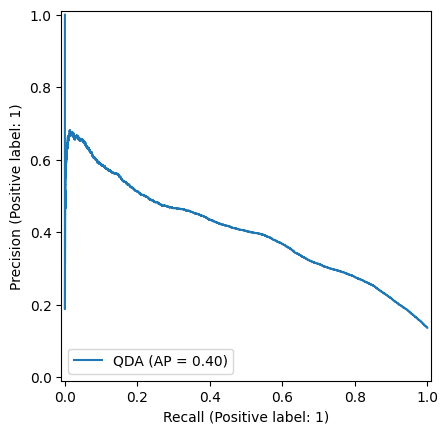

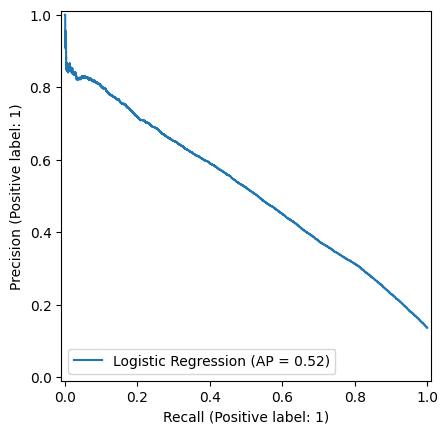

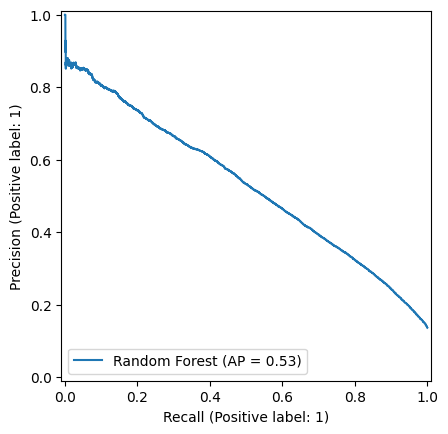

In [154]:
'''
This code is similar from week 5, we wanted to optimize this code for all models so we used the AI 
to make us the final result graph based on the the metrics we have discovered above.
'''

from sklearn.metrics import PrecisionRecallDisplay


PrecisionRecallDisplay.from_predictions(y_test_A, qda_probs_A, name='QDA')

PrecisionRecallDisplay.from_predictions(y_test_A, logreg_probs_A, name='Logistic Regression')

PrecisionRecallDisplay.from_predictions(y_test_A, rf_probs_A, name='Random Forest')

QDA is better for sensitivity with Recall (class 1)= 0.586

Random Forest is better for reliability of positive predictions with AP = 0.53

Model Evaluation in scenario B

In [137]:
'''
We used clsss notes to reference and create the r^2 then combined with ai to  AI to visualize 
the metrics in one output the RMSE and R^2 table for us. The concepts and
'''

from sklearn.metrics import r2_score, mean_squared_error

# Linear Regression
y_pred_lin_B = linearReg_pipeline.predict(X_test_B)
lin_test_r2_B = r2_score(y_test_B, y_pred_lin_B)
lin_test_rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_lin_B))

# Random Forest
y_pred_rf_B = rf_B.predict(X_test_B)
rf_test_r2_B = r2_score(y_test_B, y_pred_rf_B)
rf_test_rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_rf_B))

print(f'Linear Regression | Test R²: {lin_test_r2_B:.4f} | Test RMSE: {lin_test_rmse_B:.4f}')
print(f'Random Forest     | Test R²: {rf_test_r2_B:.4f} | Test RMSE: {rf_test_rmse_B:.4f}')

Linear Regression | Test R²: 0.3048 | Test RMSE: 6.9590
Random Forest     | Test R²: 0.3279 | Test RMSE: 6.8428


Random Forest is better at R^2 (0.327) with lower RMSE (6.8428)

## **11. Iterate**

In [138]:
'''
AI was used to intgerate PCA into QDA
'''

from sklearn.decomposition import PCA

# Step 1: Standardize predictors
scaler_pca = StandardScaler()
X_train_A_scaled = scaler_pca.fit_transform(X_train_A)
X_test_A_scaled  = scaler_pca.transform(X_test_A)

# Step 2: Fit PCA on training data only
pca_full = PCA()
X_train_A_pca_full = pca_full.fit_transform(X_train_A_scaled)
X_test_A_pca_full  = pca_full.transform(X_test_A_scaled)

In [139]:
explained_var_full = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(pca_full.explained_variance_)+1)],
    'Eigenvalue': pca_full.explained_variance_,
    'Explained Variance Ratio': pca_full.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca_full.explained_variance_ratio_)
})

explained_var_full

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,PC1,2.950329,0.113474,0.113474
1,PC2,2.054152,0.079006,0.192479
2,PC3,1.951654,0.075063,0.267543
3,PC4,1.403872,0.053995,0.321538
4,PC5,1.178807,0.045339,0.366876
5,PC6,1.150472,0.044249,0.411125
6,PC7,1.041719,0.040066,0.451191
7,PC8,1.013220,0.038970,0.490161
8,PC9,0.990549,0.038098,0.528259
9,PC10,0.957641,0.036832,0.565091


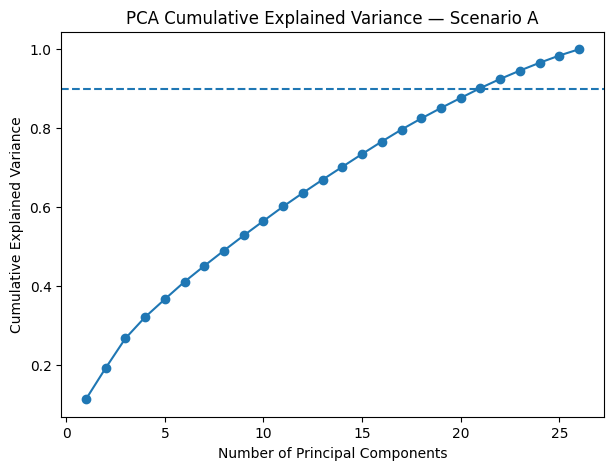

Number of PCs selected for 90% variance: 21


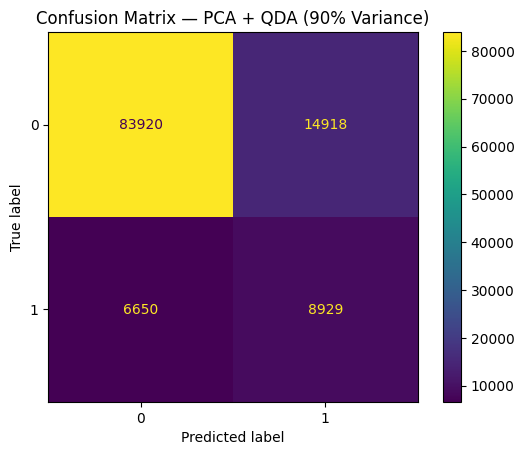

              precision    recall  f1-score   support

           0      0.927     0.849     0.886     98838
           1      0.374     0.573     0.453     15579

    accuracy                          0.811    114417
   macro avg      0.651     0.711     0.670    114417
weighted avg      0.851     0.811     0.827    114417



In [145]:
''' 
We used AI to apply PCA into the QDA code from the course materials. We also used our learning concept from 
advanced analytics to put into the code, the concept we learned are Eigenvalue and how to pick the number
of PCs to run the prediction.

this part 1, we have done some reasearches and used research to discover "90% cumulative variance" beside
Eginvalue > 1 learned from class advanced analytics. 

We decided to test and run both concept to see which one is better
'''

# PCA before QDA (Scenario A)

# Part 1: 90% cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance — Scenario A')
plt.show()

k_90 = np.argmax(cum_var >= 0.90) + 1
print("Number of PCs selected for 90% variance:", k_90)

pca_90 = PCA(n_components=k_90)
X_train_A_pca_90 = pca_90.fit_transform(X_train_A_scaled)
X_test_A_pca_90  = pca_90.transform(X_test_A_scaled)

qda_90 = QuadraticDiscriminantAnalysis()
qda_90.fit(X_train_A_pca_90, y_train_A)

pred_qda_90 = qda_90.predict(X_test_A_pca_90)

ConfusionMatrixDisplay.from_predictions(y_test_A, pred_qda_90)
plt.title('Confusion Matrix — PCA + QDA (90% Variance)')
plt.show()

print(classification_report(y_test_A, pred_qda_90, digits=3))

Number of PCs selected for eigenvalue > 1: 8


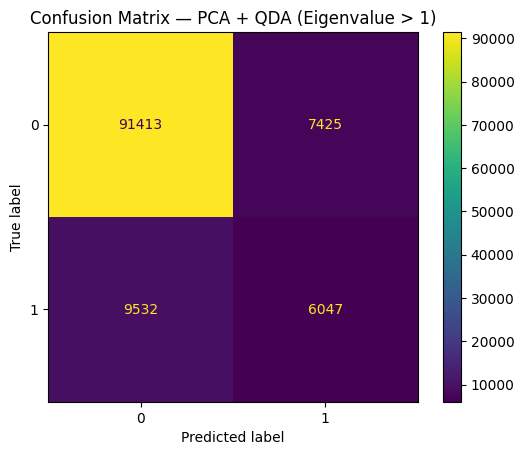

              precision    recall  f1-score   support

           0      0.906     0.925     0.915     98838
           1      0.449     0.388     0.416     15579

    accuracy                          0.852    114417
   macro avg      0.677     0.657     0.666    114417
weighted avg      0.843     0.852     0.847    114417



In [141]:
'''
we used the code and some concepts from the data mining course and advanced analytics to put into the code, 
the concepts are Eigenvalue and how to pick the number of PCs to run the prediction.

This part 2 is where we used Eigenvalue > 1 (Learned from advanced analytics class) to decided the number of PCs to run the 
prediction
'''

# Part 2: PCs had eigenvalue > 1

k_eig = np.sum(pca_full.explained_variance_ > 1)
print("Number of PCs selected for eigenvalue > 1:", k_eig)

pca_eig = PCA(n_components=k_eig)
X_train_A_pca_eig = pca_eig.fit_transform(X_train_A_scaled)
X_test_A_pca_eig  = pca_eig.transform(X_test_A_scaled)

qda_eig = QuadraticDiscriminantAnalysis()
qda_eig.fit(X_train_A_pca_eig, y_train_A)

pred_qda_eig = qda_eig.predict(X_test_A_pca_eig)

ConfusionMatrixDisplay.from_predictions(y_test_A, pred_qda_eig)
plt.title('Confusion Matrix — PCA + QDA (Eigenvalue > 1)')
plt.show()

print(classification_report(y_test_A, pred_qda_eig, digits=3))

=> The PCA + QDA Class 1 recall percentage from both methods slightly decrease (0.573 and 0.388) which suggests the orignal model will be more suitable (0.586).

## **12. Summary and Suggestions**

In [142]:
'''
We wanted to explore more in-depth the feature importance coming from QDA, we researched on
internet and AI to look for code to extract that information so we could further our analysis
'''

qda_means = pd.DataFrame(
    model_qda.means_,
    columns=X_train_A.columns,
    index=['Class 0', 'Class 1']
)

qda_effect = ((qda_means.loc['Class 1'] - qda_means.loc['Class 0']) /
              X_train_A.std()).abs().sort_values(ascending=False)

qda_effect.head(10)

ADDEPEV3    1.078577
DECIDE      1.005828
PHYSHLTH    0.850798
DIFFALON    0.660027
MEDCOST1    0.556235
DIFFDRES    0.434599
DIFFWALK    0.418681
EMPLOY1     0.312681
EXERANY2    0.298623
BLIND       0.274368
dtype: float64

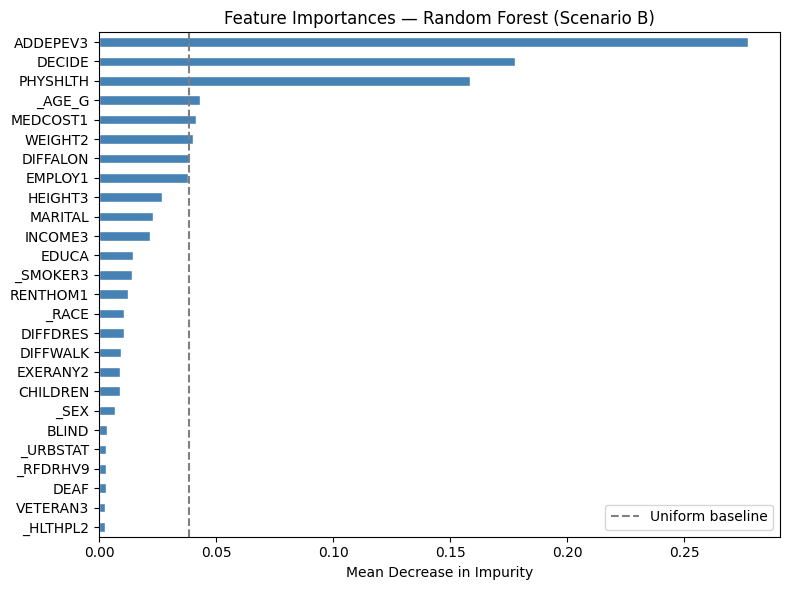

In [143]:
# Feature importance for the final Random Forest model (Scenario B)

#importances = model3.feature_importances_

importances = rf_B.feature_importances_

forest_importances_B  = pd.Series(importances, index=X_train_B.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances_B.plot.barh(ax=ax, color='steelblue', edgecolor='white')

ax.axvline(1 / len(importances), color='gray', linestyle='--', label='Uniform baseline')

ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Feature Importances — Random Forest (Scenario B)")
ax.legend()

plt.tight_layout()
plt.show()

## GenAI Usage Disclosure 

Did you use any generative AI tools (e.g., ChatGPT, Claude, Copilot, GitHub Copilot Chat) on this assignment? Yes

Did you use any other sources? (Stackoverflow, youtube videos, textbooks?)

If Yes, answer the following:
- Tool(s) used: ChatGPT
- What you used it for (e.g., debugging, explanation, generating code): debugging and generating code
- Which sections / questions it was used for: Indicated in the code line
- One sentence on how you verified or modified the output, or how it enabled you to learn: We refered to our weekly classroom learning, materials, and only used AI assistance to help us modify area to present our outcome in a better manner, and in accuracy to our objective of this project.
